# BRIDGE-Net Training Pipeline for Long-Tailed Stroke Biomarker Segmentation

This notebook implements a research prototype of **BRIDGE-Net: Biomarker-Relational Knowledge Transfer for Long-Tailed Stroke Biomarker Segmentation in Non-Contrast CT**.

The dataset, patient-level splitting, class-aware sampling/cropping, augmentation, losses, metrics, checkpointing, and evaluation logic are retained from the supplied segmentation pipeline. The updated architecture keeps the U-Net-style image backbone but introduces a **biomarker-aware multi-scale relational module**.

At the relational stage, encoder features at three spatial scales are used: **1/2 (local/fine detail), 1/4 (regional context), and 1/8 (global/coarse context)**. Learnable biomarker tokens retrieve evidence from each scale through cross-attention, learn a biomarker-specific weighting over the scales, exchange information across scales, and then model biomarker-to-biomarker relationships through self-attention. Frequency-aware rarity gating and common-source bias are retained for the long-tailed setting.

The final masks are produced by comparing learned biomarker representations with the full-resolution decoder features.

> **Important:** This is a research prototype for experimentation, not yet a validated novelty claim. A formal literature novelty audit and ablation studies are still required before presenting BRIDGE-Net as a new method.


## 1. Install dependencies

In [1]:
# Run once in a fresh notebook environment, then restart the kernel if required.
%pip install -q \
  torch torchvision \
  numpy pandas matplotlib pillow opencv-python-headless \
  albumentations scikit-learn scipy tqdm tensorboard

Note: you may need to restart the kernel to use updated packages.


## 2. Imports and environment checks

In [2]:
from __future__ import annotations

import hashlib
import json
import math
import os
import pickle
import random
import subprocess
import sys
import time
import warnings

from collections import Counter, defaultdict
from dataclasses import asdict, dataclass, is_dataclass
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Sequence, Set, Tuple, Union

import albumentations as A
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from albumentations.pytorch import ToTensorV2
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from PIL import Image
from scipy.ndimage import binary_erosion, distance_transform_edt
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torch.utils.tensorboard import SummaryWriter
from tqdm.auto import tqdm

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: 3.12.14
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5090


## Biomarker class representation

INITIAL RAW DATASET EXPLORATION
Dataset root       : /workspace/bash_phd/ml_pipeline/stroke_dataset
Paired CT samples  : 941
Detected partitions: all


Analysing raw annotations:   0%|          | 0/941 [00:00<?, ?it/s]

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.
findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


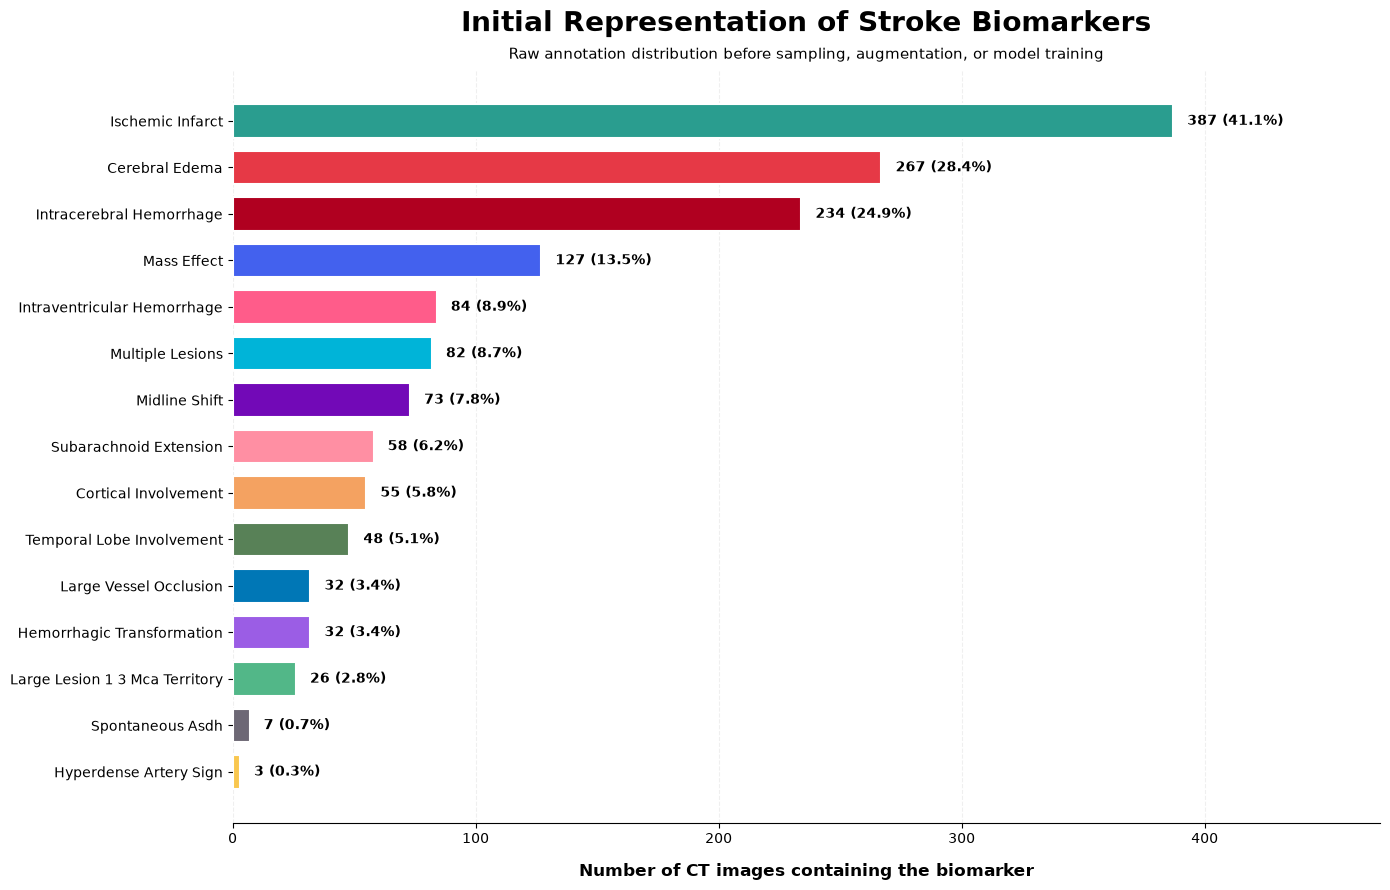

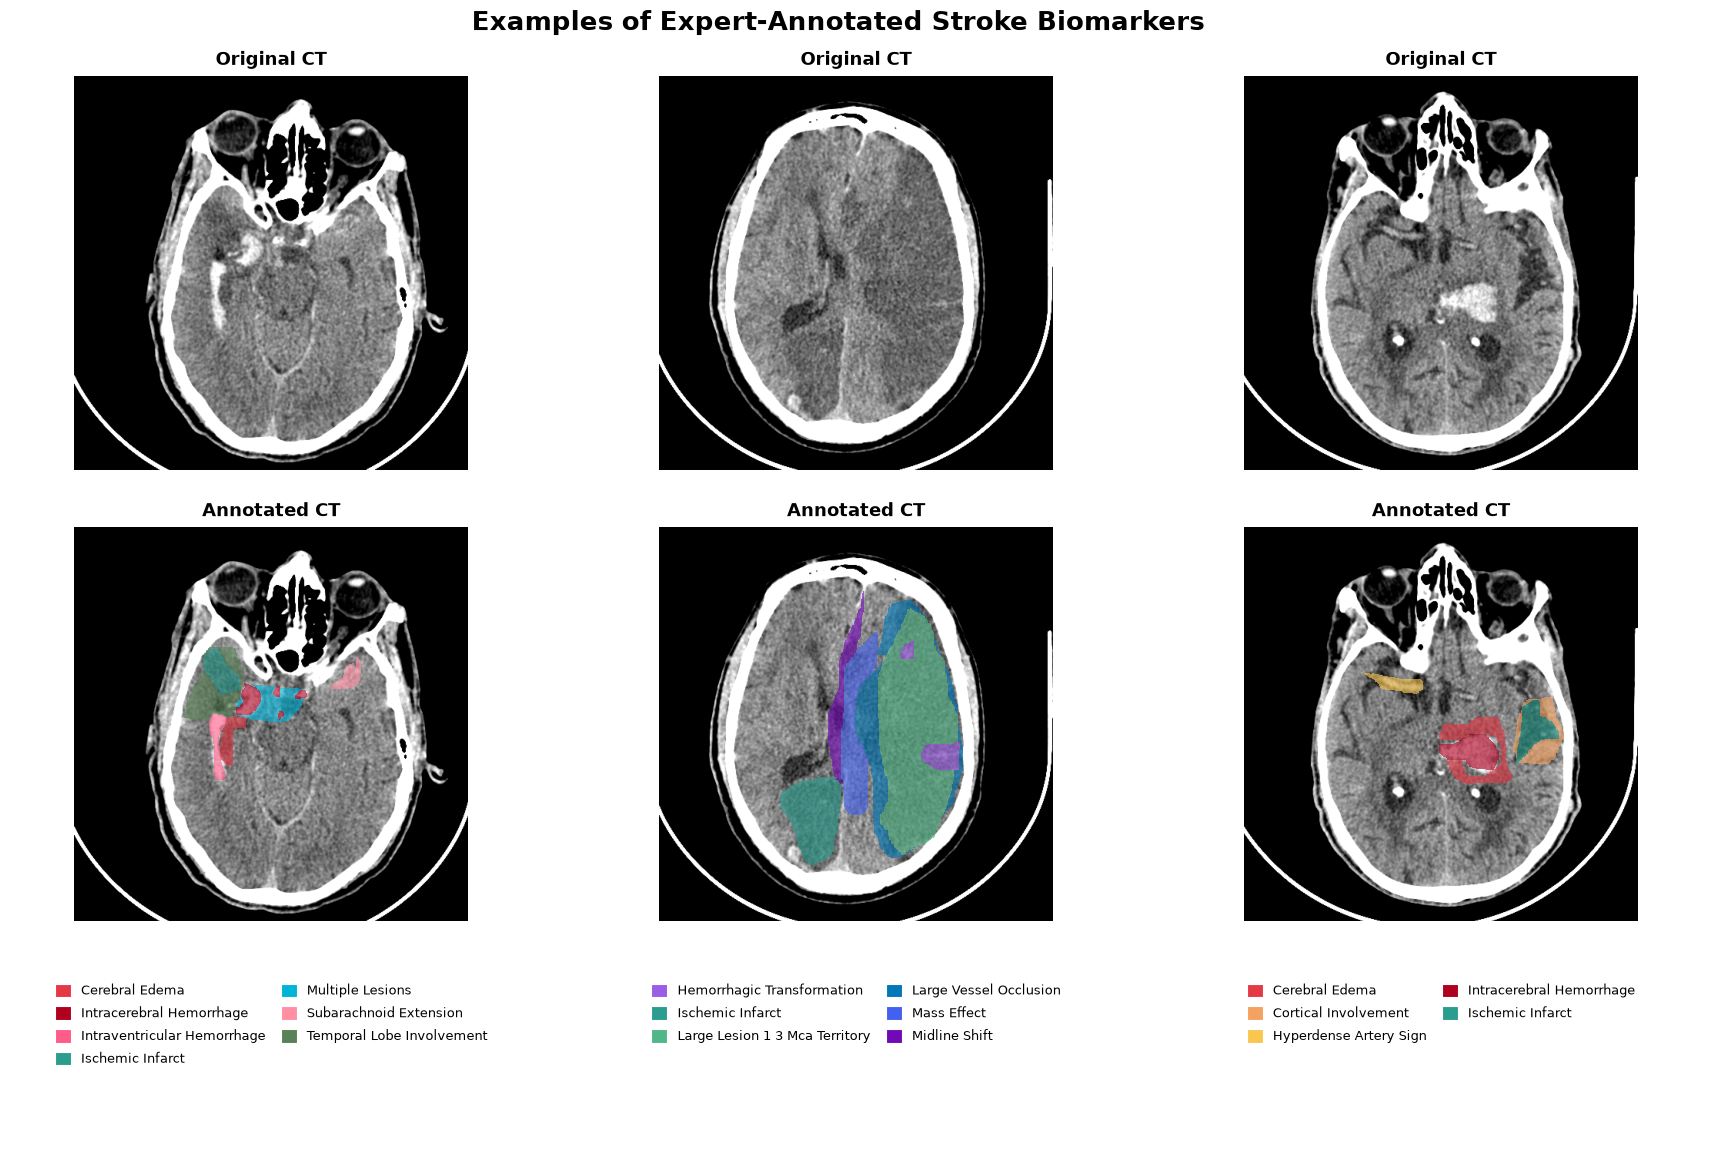


Biomarker representation summary:


,class_id,biomarker,samples_with_biomarker,sample_percentage,pixel_count,pixel_percentage
0,7,Ischemic Infarct,387,41.13,1281104,0.5193
1,1,Cerebral Edema,267,28.37,1330813,0.5394
2,5,Intracerebral Hemorrhage,234,24.87,500958,0.2031
3,10,Mass Effect,127,13.50,418055,0.1694
4,6,Intraventricular Hemorrhage,84,8.93,159966,0.0648
5,12,Multiple Lesions,82,8.71,169023,0.0685
6,11,Midline Shift,73,7.76,163776,0.0664
7,14,Subarachnoid Extension,58,6.16,191846,0.0778
8,2,Cortical Involvement,55,5.84,75169,0.0305
9,15,Temporal Lobe Involvement,48,5.10,119430,0.0484


In [3]:
# ============================================================
# INITIAL DATASET EXPLORATION
# Biomarker representation + colour-coded annotated CT samples
# Run BEFORE the Central Configuration cell
# ============================================================

# ------------------------------------------------------------
# 1. Dataset path and biomarker definitions
# ------------------------------------------------------------

INITIAL_DATASET_ROOT = Path("stroke_dataset").resolve()

INITIAL_CLASS_NAMES = {
    0: "background",
    1: "cerebral_edema",
    2: "cortical_involvement",
    3: "hemorrhagic_transformation",
    4: "hyperdense_artery_sign",
    5: "intracerebral_hemorrhage",
    6: "intraventricular_hemorrhage",
    7: "ischemic_infarct",
    8: "large_lesion_1_3_mca_territory",
    9: "large_vessel_occlusion",
    10: "mass_effect",
    11: "midline_shift",
    12: "multiple_lesions",
    13: "spontaneous_asdh",
    14: "subarachnoid_extension",
    15: "temporal_lobe_involvement",
}

INITIAL_NUM_CLASSES = len(INITIAL_CLASS_NAMES)

IMAGE_EXTENSIONS = {
    ".png", ".jpg", ".jpeg",
    ".tif", ".tiff", ".bmp"
}

MASK_EXTENSIONS = IMAGE_EXTENSIONS.copy()


# ------------------------------------------------------------
# 2. Fixed biomarker colour palette
# ------------------------------------------------------------
# IMPORTANT:
# The exact same colours are used in:
#   - the biomarker representation graph
#   - annotation overlays
#   - the colour legend
#
# This gives each biomarker a permanent visual identity.

BIOMARKER_COLORS = {
    0:  "#000000",   # Background
    1:  "#E63946",   # Cerebral edema
    2:  "#F4A261",   # Cortical involvement
    3:  "#9B5DE5",   # Hemorrhagic transformation
    4:  "#F9C74F",   # Hyperdense artery sign
    5:  "#B00020",   # Intracerebral hemorrhage
    6:  "#FF5C8A",   # Intraventricular hemorrhage
    7:  "#2A9D8F",   # Ischemic infarct
    8:  "#52B788",   # Large lesion > 1/3 MCA territory
    9:  "#0077B6",   # Large vessel occlusion
    10: "#4361EE",   # Mass effect
    11: "#7209B7",   # Midline shift
    12: "#00B4D8",   # Multiple lesions
    13: "#6D6875",   # Spontaneous ASDH
    14: "#FF8FA3",   # Subarachnoid extension
    15: "#588157",   # Temporal lobe involvement
}


BIOMARKER_CMAP = ListedColormap([
    BIOMARKER_COLORS[class_id]
    for class_id in range(INITIAL_NUM_CLASSES)
])

BIOMARKER_NORM = BoundaryNorm(
    np.arange(
        -0.5,
        INITIAL_NUM_CLASSES + 0.5
    ),
    BIOMARKER_CMAP.N
)


def biomarker_colour(class_id):
    return BIOMARKER_COLORS[int(class_id)]


def pretty_biomarker_name(class_id):
    return (
        INITIAL_CLASS_NAMES[int(class_id)]
        .replace("_", " ")
        .title()
    )


# ------------------------------------------------------------
# 3. File indexing
# ------------------------------------------------------------

def initial_index_files(folder, extensions):

    folder = Path(folder)

    if not folder.exists():
        raise FileNotFoundError(
            f"Folder not found: {folder}"
        )

    files = [
        path
        for path in folder.rglob("*")
        if (
            path.is_file()
            and path.suffix.lower() in extensions
        )
    ]

    index = {}

    for path in files:

        if path.stem in index:
            raise ValueError(
                f"Duplicate filename stem detected: "
                f"{path.stem}"
            )

        index[path.stem] = path

    return index


# ------------------------------------------------------------
# 4. Detect dataset organisation
# ------------------------------------------------------------

def initial_find_dataset_partitions(root):

    root = Path(root)

    # Unsplit dataset:
    #
    # stroke_dataset/
    #     images/
    #     masks/

    if (
        (root / "images").exists()
        and
        (root / "masks").exists()
    ):

        return {
            "all": root
        }


    # Already split dataset:
    #
    # stroke_dataset/
    #     train/
    #         images/
    #         masks/
    #     val/
    #     test/

    aliases = {

        "train": (
            "train",
            "training"
        ),

        "val": (
            "val",
            "validation",
            "valid"
        ),

        "test": (
            "test",
            "testing"
        )
    }


    partitions = {}

    for split_name, candidates in aliases.items():

        for candidate in candidates:

            split_dir = root / candidate

            if (
                (split_dir / "images").exists()
                and
                (split_dir / "masks").exists()
            ):

                partitions[split_name] = split_dir
                break


    if not partitions:

        raise FileNotFoundError(

            f"Could not recognise the dataset "
            f"structure under:\n{root}\n\n"

            "Expected either:\n\n"

            "stroke_dataset/\n"
            "    images/\n"
            "    masks/\n\n"

            "OR\n\n"

            "stroke_dataset/\n"
            "    train/images/\n"
            "    train/masks/\n"
            "    val/images/\n"
            "    val/masks/\n"
            "    test/images/\n"
            "    test/masks/"
        )


    return partitions


# ------------------------------------------------------------
# 5. Image reader
# ------------------------------------------------------------

def initial_read_image(path):

    image = cv2.imread(
        str(path),
        cv2.IMREAD_UNCHANGED
    )

    if image is None:

        raise ValueError(
            f"Could not read image:\n{path}"
        )


    if image.ndim == 3:

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )


    return image


# ------------------------------------------------------------
# 6. Mask reader
# ------------------------------------------------------------

def initial_read_mask(path):

    mask = cv2.imread(
        str(path),
        cv2.IMREAD_UNCHANGED
    )


    if mask is None:

        raise ValueError(
            f"Could not read mask:\n{path}"
        )


    # If saved as RGB but the three channels are identical,
    # convert to a single integer-class channel.

    if mask.ndim == 3:

        channels_identical = (

            np.array_equal(
                mask[..., 0],
                mask[..., 1]
            )

            and

            np.array_equal(
                mask[..., 1],
                mask[..., 2]
            )
        )


        if not channels_identical:

            raise ValueError(

                "Mask appears to be colour-coded "
                "instead of containing integer class IDs:\n"
                f"{path}"
            )


        mask = mask[..., 0]


    mask = mask.astype(np.int64)


    unexpected_classes = (

        set(
            int(x)
            for x in np.unique(mask)
        )

        -

        set(
            INITIAL_CLASS_NAMES.keys()
        )
    )


    if unexpected_classes:

        raise ValueError(

            f"Unexpected class IDs "
            f"{sorted(unexpected_classes)} "
            f"found in:\n{path}"
        )


    return mask


# ============================================================
# 7. LOAD AND PAIR THE DATASET
# ============================================================

partitions = initial_find_dataset_partitions(
    INITIAL_DATASET_ROOT
)


initial_pairs = []


for split_name, split_root in partitions.items():

    image_index = initial_index_files(

        split_root / "images",

        IMAGE_EXTENSIONS
    )


    mask_index = initial_index_files(

        split_root / "masks",

        MASK_EXTENSIONS
    )


    image_ids = set(
        image_index.keys()
    )

    mask_ids = set(
        mask_index.keys()
    )


    missing_masks = (
        image_ids - mask_ids
    )

    missing_images = (
        mask_ids - image_ids
    )


    if missing_masks or missing_images:

        raise ValueError(

            f"Image-mask mismatch in "
            f"'{split_name}'\n\n"

            f"Images without masks: "
            f"{len(missing_masks)}\n"

            f"Masks without images: "
            f"{len(missing_images)}"
        )


    for sample_id in sorted(image_ids):

        initial_pairs.append({

            "split":
                split_name,

            "sample_id":
                sample_id,

            "image_path":
                image_index[sample_id],

            "mask_path":
                mask_index[sample_id],
        })


initial_dataset_df = pd.DataFrame(
    initial_pairs
)


if initial_dataset_df.empty:

    raise RuntimeError(
        "No paired images and masks were found."
    )


print("=" * 72)

print(
    "INITIAL RAW DATASET EXPLORATION"
)

print("=" * 72)

print(
    f"Dataset root       : "
    f"{INITIAL_DATASET_ROOT}"
)

print(
    f"Paired CT samples  : "
    f"{len(initial_dataset_df):,}"
)

print(
    "Detected partitions: "
    + ", ".join(partitions.keys())
)


# ============================================================
# 8. CALCULATE INITIAL BIOMARKER REPRESENTATION
# ============================================================

pixel_counts = Counter()

sample_counts = Counter()

sample_biomarkers = {}

total_pixels = 0


for row in tqdm(

    initial_dataset_df.itertuples(),

    total=len(initial_dataset_df),

    desc="Analysing raw annotations"
):

    mask = initial_read_mask(
        row.mask_path
    )


    class_ids, counts = np.unique(

        mask,

        return_counts=True
    )


    total_pixels += mask.size


    foreground_classes = []


    for class_id, count in zip(
        class_ids,
        counts
    ):

        class_id = int(
            class_id
        )

        count = int(
            count
        )


        pixel_counts[
            class_id
        ] += count


        sample_counts[
            class_id
        ] += 1


        if class_id != 0:

            foreground_classes.append(
                class_id
            )


    sample_biomarkers[
        row.sample_id
    ] = foreground_classes


# ------------------------------------------------------------
# Create representation dataframe
# ------------------------------------------------------------

number_of_samples = len(
    initial_dataset_df
)


representation_rows = []


for class_id in range(
    1,
    INITIAL_NUM_CLASSES
):

    number_present = sample_counts[
        class_id
    ]


    sample_percentage = (

        100
        * number_present
        / number_of_samples

        if number_of_samples > 0
        else 0
    )


    pixel_percentage = (

        100
        * pixel_counts[class_id]
        / total_pixels

        if total_pixels > 0
        else 0
    )


    representation_rows.append({

        "class_id":
            class_id,

        "biomarker":
            pretty_biomarker_name(
                class_id
            ),

        "samples_with_biomarker":
            number_present,

        "sample_percentage":
            sample_percentage,

        "pixel_count":
            pixel_counts[class_id],

        "pixel_percentage":
            pixel_percentage,
    })


initial_biomarker_report = pd.DataFrame(
    representation_rows
)


# ============================================================
# 9. BEAUTIFUL COLOUR-CODED BIOMARKER REPRESENTATION GRAPH
# ============================================================

plot_report = (

    initial_biomarker_report

    .sort_values(
        "samples_with_biomarker",
        ascending=True
    )

    .reset_index(
        drop=True
    )
)


bar_colors = [

    BIOMARKER_COLORS[
        int(class_id)
    ]

    for class_id
    in plot_report["class_id"]
]


fig, ax = plt.subplots(
    figsize=(14, 9)
)


bars = ax.barh(

    plot_report["biomarker"],

    plot_report[
        "samples_with_biomarker"
    ],

    color=bar_colors,

    edgecolor="white",

    linewidth=1.5,

    height=0.72
)


max_count = max(

    int(
        plot_report[
            "samples_with_biomarker"
        ].max()
    ),

    1
)


# ------------------------------------------------------------
# Add counts and percentages
# ------------------------------------------------------------

for bar, row in zip(
    bars,
    plot_report.itertuples()
):

    ax.text(

        bar.get_width()
        + max_count * 0.015,

        bar.get_y()
        + bar.get_height() / 2,

        (
            f"{row.samples_with_biomarker:,} "
            f"({row.sample_percentage:.1f}%)"
        ),

        va="center",

        ha="left",

        fontsize=10,

        fontweight="semibold"
    )


# ------------------------------------------------------------
# Graph styling
# ------------------------------------------------------------

ax.set_title(

    "Initial Representation of Stroke Biomarkers",

    fontsize=20,

    fontweight="bold",

    pad=28
)


ax.text(

    0.5,

    1.015,

    (
        "Raw annotation distribution before "
        "sampling, augmentation, or model training"
    ),

    transform=ax.transAxes,

    ha="center",

    fontsize=11
)


ax.set_xlabel(

    "Number of CT images containing the biomarker",

    fontsize=12,

    fontweight="semibold",

    labelpad=12
)


ax.set_ylabel("")


ax.tick_params(

    axis="y",

    labelsize=10
)


ax.tick_params(

    axis="x",

    labelsize=10
)


ax.grid(

    axis="x",

    linestyle="--",

    linewidth=0.8,

    alpha=0.20
)


ax.set_axisbelow(
    True
)


# Remove unnecessary border lines
ax.spines[
    "top"
].set_visible(False)

ax.spines[
    "right"
].set_visible(False)

ax.spines[
    "left"
].set_visible(False)


ax.set_xlim(
    0,
    max_count * 1.22
)


plt.tight_layout()

plt.show()


# ============================================================
# 10. SELECT 3 INFORMATIVE ANNOTATED CT IMAGES
# ============================================================
# Rather than randomly selecting images, select samples that
# collectively show as many different biomarkers as possible.

annotated_candidates = []


for row in initial_dataset_df.itertuples():

    foreground_classes = set(

        sample_biomarkers[
            row.sample_id
        ]
    )


    if foreground_classes:

        annotated_candidates.append({

            "sample_id":
                row.sample_id,

            "image_path":
                row.image_path,

            "mask_path":
                row.mask_path,

            "classes":
                foreground_classes,
        })


if len(annotated_candidates) == 0:

    print(
        "\nNo foreground annotated samples "
        "were found."
    )


else:

    selected_samples = []

    covered_classes = set()

    remaining_samples = (
        annotated_candidates.copy()
    )


    while (

        len(selected_samples) < 3

        and

        len(remaining_samples) > 0
    ):

        best_sample = max(

            remaining_samples,

            key=lambda sample: (

                len(
                    sample["classes"]
                    - covered_classes
                ),

                len(
                    sample["classes"]
                )
            )
        )


        selected_samples.append(
            best_sample
        )


        covered_classes.update(
            best_sample["classes"]
        )


        remaining_samples.remove(
            best_sample
        )


# ============================================================
# DISPLAY 3 ANNOTATED CT EXAMPLES
# Clean layout with non-overlapping biomarker labels
# ============================================================

n_examples = len(selected_samples)

# 3 rows:
# Row 1 = original CT
# Row 2 = annotated CT
# Row 3 = biomarker colour key for that image
fig, axes = plt.subplots(
    3,
    n_examples,
    figsize=(6 * n_examples, 12),
    gridspec_kw={
        "height_ratios": [1, 1, 0.42]
    },
    squeeze=False
)

displayed_classes = set()


for column, sample in enumerate(selected_samples):

    image = initial_read_image(
        sample["image_path"]
    )

    mask = initial_read_mask(
        sample["mask_path"]
    )

    foreground_classes = [
        int(class_id)
        for class_id in np.unique(mask)
        if int(class_id) != 0
    ]

    displayed_classes.update(
        foreground_classes
    )

    image_cmap = (
        "gray"
        if image.ndim == 2
        else None
    )


    # ========================================================
    # ROW 1 — ORIGINAL CT
    # ========================================================

    axes[0, column].imshow(
        image,
        cmap=image_cmap
    )

    axes[0, column].set_title(
        "Original CT",
        fontsize=13,
        fontweight="bold",
        pad=8
    )

    axes[0, column].axis("off")


    # ========================================================
    # ROW 2 — ANNOTATED CT
    # ========================================================

    axes[1, column].imshow(
        image,
        cmap=image_cmap
    )

    # Hide background class
    overlay = np.ma.masked_where(
        mask == 0,
        mask
    )

    axes[1, column].imshow(
        overlay,
        cmap=BIOMARKER_CMAP,
        norm=BIOMARKER_NORM,
        alpha=0.62,
        interpolation="nearest"
    )

    axes[1, column].set_title(
        "Annotated CT",
        fontsize=13,
        fontweight="bold",
        pad=8
    )

    axes[1, column].axis("off")


    # ========================================================
    # ROW 3 — BIOMARKERS PRESENT IN THIS IMAGE
    # ========================================================

    axes[2, column].axis("off")

    if foreground_classes:

        image_legend = [
            Patch(
                facecolor=BIOMARKER_COLORS[class_id],
                edgecolor="white",
                linewidth=0.8,
                label=pretty_biomarker_name(class_id)
            )
            for class_id in foreground_classes
        ]

        axes[2, column].legend(
            handles=image_legend,

            loc="upper center",

            bbox_to_anchor=(0.5, 1.0),

            # Two columns prevents a very long vertical list
            ncol=2 if len(image_legend) > 3 else 1,

            fontsize=9,

            frameon=False,

            handlelength=1.3,

            handleheight=1.3,

            columnspacing=1.2,

            labelspacing=0.7,

            borderaxespad=0
        )

    else:

        axes[2, column].text(
            0.5,
            0.8,
            "No foreground biomarker",
            ha="center",
            va="center",
            fontsize=9
        )


# ============================================================
# MAIN FIGURE TITLE
# ============================================================

fig.suptitle(
    "Examples of Expert-Annotated Stroke Biomarkers",
    fontsize=19,
    fontweight="bold",
    y=0.995
)


# ------------------------------------------------------------
# Spacing
# ------------------------------------------------------------

plt.subplots_adjust(
    top=0.94,
    bottom=0.05,
    left=0.04,
    right=0.98,
    hspace=0.18,
    wspace=0.12
)

plt.show()


# ============================================================
# 13. NUMERICAL REPRESENTATION SUMMARY
# ============================================================

print(
    "\nBiomarker representation summary:"
)


display(

    initial_biomarker_report[
        [
            "class_id",
            "biomarker",
            "samples_with_biomarker",
            "sample_percentage",
            "pixel_count",
            "pixel_percentage",
        ]
    ]

    .sort_values(
        "samples_with_biomarker",
        ascending=False
    )

    .reset_index(
        drop=True
    )

    .round({
        "sample_percentage": 2,
        "pixel_percentage": 4
    })
)

## 3. Central configuration

In [4]:
CLASS_NAMES: Dict[int, str] = {
    0: "background",
    1: "cerebral_edema",
    2: "cortical_involvement",
    3: "hemorrhagic_transformation",
    4: "hyperdense_artery_sign",
    5: "intracerebral_hemorrhage",
    6: "intraventricular_hemorrhage",
    7: "ischemic_infarct",
    8: "large_lesion_1_3_mca_territory",
    9: "large_vessel_occlusion",
    10: "mass_effect",
    11: "midline_shift",
    12: "multiple_lesions",
    13: "spontaneous_asdh",
    14: "subarachnoid_extension",
    15: "temporal_lobe_involvement",
}


@dataclass(frozen=True)
class Config:
    # Paths
    dataset_root: str = "stroke_dataset"
    output_root: str = "outputs/bridgenet_stroke"

    # Dataset and splitting
    train_ratio: float = 0.70
    val_ratio: float = 0.15
    test_ratio: float = 0.15
    image_size: int = 256
    num_classes: int = len(CLASS_NAMES)
    ignore_index: int = 255
    seed: int = 42

    image_extensions: Tuple[str, ...] = (
        ".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"
    )
    mask_extensions: Tuple[str, ...] = (
        ".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"
    )

    # Example:
    # patient001_slice003 with delimiter "_slice" -> patient001
    patient_id_delimiter: Optional[str] = None

    # BRIDGE-Net image backbone
    input_channels: int = 3
    unet_channels: Tuple[int, int, int, int, int] = (
        32, 64, 128, 256, 512
    )
    unet_dropout: float = 0.15
    group_norm_max_groups: int = 8

    # BRIDGE-Net relational module
    bridge_relation_dim: int = 128
    bridge_num_heads: int = 4
    bridge_relation_grid_size: int = 32
    # Multi-scale relational reasoning uses encoder features at 1/2, 1/4 and 1/8 resolution.
    bridge_scale_names: Tuple[str, str, str] = (
        "local_1_2",
        "regional_1_4",
        "global_1_8",
    )
    bridge_rarity_gate_strength: float = 1.50
    bridge_common_source_bias: float = 1.00
    bridge_residual_head_weight: float = 0.25

    # Optional matching-layer warm start. Leave None to train from scratch.
    warmstart_checkpoint: Optional[str] = None

    # Class-aware augmentation
    use_class_aware_sampling: bool = True
    use_class_centered_crops: bool = True
    max_sampling_multiplier: float = 6.0
    background_only_sample_weight: float = 0.60
    class_crop_probability: float = 0.75
    minimum_crop_size: int = 192
    maximum_crop_size: int = 320

    # Training
    epochs: int = 150
    batch_size: int = 4
    num_workers: int = 4
    learning_rate: float = 1e-4
    min_learning_rate: float = 1e-6
    weight_decay: float = 1e-4
    warmup_epochs: int = 5
    early_stopping_patience: int = 20
    gradient_clip_norm: float = 1.0
    amp: bool = True

    # Loss
    ce_weight: float = 0.5
    dice_weight: float = 0.5
    class_weight_min: float = 0.10
    class_weight_max: float = 3.00

    # Runtime
    deterministic: bool = True
    pin_memory: bool = True
    persistent_workers: bool = True


CFG = Config()
ALLOWED_CLASS_IDS: Set[int] = set(range(CFG.num_classes))

assert set(CLASS_NAMES) == ALLOWED_CLASS_IDS, "CLASS_NAMES IDs must be contiguous from 0 to num_classes-1."
assert math.isclose(CFG.train_ratio + CFG.val_ratio + CFG.test_ratio, 1.0)
assert CFG.image_size % 16 == 0, "U-Net input size should be divisible by 16."
assert len(CFG.unet_channels) == 5
assert all(channel > 0 for channel in CFG.unet_channels)

DATASET_ROOT = Path(CFG.dataset_root).resolve()
OUTPUT_ROOT = Path(CFG.output_root).resolve()
CHECKPOINT_DIR = OUTPUT_ROOT / "checkpoints"
LOG_DIR = OUTPUT_ROOT / "logs"
PREDICTION_DIR = OUTPUT_ROOT / "predictions"

for directory in (OUTPUT_ROOT, CHECKPOINT_DIR, LOG_DIR, PREDICTION_DIR):
    directory.mkdir(parents=True, exist_ok=True)

with (OUTPUT_ROOT / "config.json").open("w", encoding="utf-8") as file:
    json.dump(asdict(CFG), file, indent=2)

print(json.dumps(asdict(CFG), indent=2))

{
  "dataset_root": "stroke_dataset",
  "output_root": "outputs/bridgenet_stroke",
  "train_ratio": 0.7,
  "val_ratio": 0.15,
  "test_ratio": 0.15,
  "image_size": 256,
  "num_classes": 16,
  "ignore_index": 255,
  "seed": 42,
  "image_extensions": [
    ".png",
    ".jpg",
    ".jpeg",
    ".tif",
    ".tiff",
    ".bmp"
  ],
  "mask_extensions": [
    ".png",
    ".jpg",
    ".jpeg",
    ".tif",
    ".tiff",
    ".bmp"
  ],
  "patient_id_delimiter": null,
  "input_channels": 3,
  "unet_channels": [
    32,
    64,
    128,
    256,
    512
  ],
  "unet_dropout": 0.15,
  "group_norm_max_groups": 8,
  "bridge_relation_dim": 128,
  "bridge_num_heads": 4,
  "bridge_relation_grid_size": 32,
  "bridge_scale_names": [
    "local_1_2",
    "regional_1_4",
    "global_1_8"
  ],
  "bridge_rarity_gate_strength": 1.5,
  "bridge_common_source_bias": 1.0,
  "bridge_residual_head_weight": 0.25,
  "warmstart_checkpoint": null,
  "use_class_aware_sampling": true,
  "use_class_centered_crops": true,
 

## 4. Reproducibility and device setup

In [5]:
def seed_everything(seed: int, deterministic: bool = True) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if deterministic:
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True
        try:
            torch.use_deterministic_algorithms(True, warn_only=True)
        except TypeError:
            torch.use_deterministic_algorithms(True)
    else:
        torch.backends.cudnn.benchmark = True
        torch.backends.cudnn.deterministic = False


seed_everything(CFG.seed, CFG.deterministic)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


## 5. Define the BRIDGE-Net architecture

BRIDGE-Net retains a U-Net-like encoder-decoder for spatial localization, but its relational stage is now **biomarker-aware and multi-scale**. Instead of reading only the final decoder feature map, the relational module receives three encoder representations at different resolutions:

- **1/2 resolution — local context:** fine spatial detail and small/focal biomarkers.
- **1/4 resolution — regional context:** lesion extent and surrounding anatomical relationships.
- **1/8 resolution — global context:** broad anatomical organization and large-scale findings such as displacement.

Each foreground biomarker is represented by a learnable token. The token uses image cross-attention to retrieve CT evidence independently from each scale. A learned **biomarker-specific scale gate** then determines how much local, regional, and global evidence should contribute for that biomarker. The scale-specific evidence is also passed through explicit cross-scale attention so that information at one resolution can interact with information at the other resolutions.

The fused biomarker representations then exchange information through biomarker self-attention. Long-tail transfer is retained through two frequency-aware mechanisms: **common-source bias**, which softly favours well-represented biomarkers as knowledge sources, and a **rarity gate**, which allows rarer biomarker queries to receive a stronger relational residual.

The segmentation head compares each learned biomarker representation with full-resolution decoder features to produce dense multiclass logits.

### High-level data flow

`CT → U-Net encoder → {1/2 local, 1/4 regional, 1/8 global} → biomarker-aware multi-scale cross-attention → biomarker-specific scale gating → cross-scale fusion → biomarker self-attention → FFN refinement → decoder-conditioned segmentation head → 15-biomarker segmentation map`

> **Scope note:** The current notebook is a **segmentation-only** pipeline with 15 foreground stroke-biomarker classes plus background. PSE prediction is not added as a segmentation class here; it should be implemented as a separate prediction head/task if required.


## BRIDGE-Net architecture update: what changed

The previous relational module read one feature map. The updated module reads **three encoder feature maps** and explicitly models relationships across spatial scales:

```text
CT
 ↓
U-Net encoder
 ├── 1/2  → local/fine evidence ───────┐
 ├── 1/4  → regional evidence ─────────┼→ biomarker cross-attention
 └── 1/8  → global/coarse evidence ────┘             ↓
                                      biomarker-specific scale gates
                                                     ↓
                                      cross-scale attention + fusion
                                                     ↓
                                      biomarker self-attention
                                                     ↓
                                      LayerNorm + FFN refinement
                                                     ↓
                                      decoder-conditioned head
                                                     ↓
                                      15-class biomarker segmentation
```

The architectural motivation is that stroke biomarkers are not spatially uniform: some are tiny and require fine local detail, while others depend on regional anatomy or global brain organization. The model therefore learns **which scale(s) are useful for each biomarker** instead of forcing every biomarker to use the same receptive context.


In [6]:
def compatible_group_count(
    channels: int,
    maximum_groups: int,
) -> int:
    """Choose the largest valid GroupNorm group count."""
    for groups in range(min(maximum_groups, channels), 0, -1):
        if channels % groups == 0:
            return groups
    return 1


class DoubleConv(nn.Module):
    """Two 3x3 convolutions with GroupNorm and ReLU."""

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        maximum_groups: int = 8,
    ) -> None:
        super().__init__()

        groups = compatible_group_count(out_channels, maximum_groups)
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.GroupNorm(groups, out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.GroupNorm(groups, out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class DownBlock(nn.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        maximum_groups: int = 8,
    ) -> None:
        super().__init__()
        self.block = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels, maximum_groups),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class UpBlock(nn.Module):
    def __init__(
        self,
        in_channels: int,
        skip_channels: int,
        out_channels: int,
        maximum_groups: int = 8,
    ) -> None:
        super().__init__()
        self.upsample = nn.ConvTranspose2d(in_channels, out_channels, 2, stride=2)
        self.convolutions = DoubleConv(
            out_channels + skip_channels,
            out_channels,
            maximum_groups,
        )

    def forward(self, x: torch.Tensor, skip: torch.Tensor) -> torch.Tensor:
        x = self.upsample(x)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        return self.convolutions(torch.cat([skip, x], dim=1))


class BiomarkerRelationalTransfer(nn.Module):
    """
    BRIDGE-Net biomarker-aware multi-scale relational core.

    The module consumes three encoder feature levels:
      * 1/2 resolution: local/fine spatial context;
      * 1/4 resolution: regional context;
      * 1/8 resolution: global/coarse context.

    Each foreground biomarker is represented by a learnable token. The token
    retrieves CT evidence from every scale with image cross-attention. A
    biomarker-specific scale gate learns how much evidence to use from each
    resolution. Scale evidence is then allowed to interact through explicit
    cross-scale attention before the biomarker tokens exchange information via
    biomarker self-attention.

    Long-tail transfer is encouraged in two ways:
      1. common-source bias: frequent biomarkers receive a positive key bias;
      2. rarity gate: rare biomarker queries receive a larger relational residual.

    The module does not hard-code clinical relationships. Learned attention is
    an internal model signal and must not be interpreted as causal evidence.
    """

    def __init__(
        self,
        num_foreground_classes: int,
        image_channels: Sequence[int],
        relation_dim: int = 128,
        num_heads: int = 4,
        relation_grid_size: int = 32,
        rarity_gate_strength: float = 1.5,
        common_source_bias: float = 1.0,
    ) -> None:
        super().__init__()
        if relation_dim % num_heads != 0:
            raise ValueError("relation_dim must be divisible by num_heads")
        if len(image_channels) != 3:
            raise ValueError("Multi-scale relational transfer expects three image channel levels: 1/2, 1/4, 1/8")
        if relation_grid_size < 8:
            raise ValueError("relation_grid_size must be at least 8 for three scale-specific grids")

        self.num_foreground_classes = int(num_foreground_classes)
        self.relation_dim = int(relation_dim)
        self.relation_grid_size = int(relation_grid_size)
        self.rarity_gate_strength = float(rarity_gate_strength)
        self.common_source_bias_strength = float(common_source_bias)
        self.num_scales = 3
        self.scale_names = ("local_1_2", "regional_1_4", "global_1_8")

        # Each encoder level is projected into the shared relational space.
        self.scale_projections = nn.ModuleList([
            nn.Conv2d(int(channels), relation_dim, kernel_size=1, bias=False)
            for channels in image_channels
        ])

        # Scale embeddings tell the attention mechanism which resolution it is reading.
        self.scale_embeddings = nn.Parameter(
            torch.randn(1, self.num_scales, relation_dim) * 0.02
        )

        self.biomarker_tokens = nn.Parameter(
            torch.randn(1, num_foreground_classes, relation_dim) * 0.02
        )

        # Built-in PyTorch multi-head attention is reused for image -> biomarker evidence.
        self.image_cross_attention = nn.MultiheadAttention(
            embed_dim=relation_dim,
            num_heads=num_heads,
            batch_first=True,
        )

        # Explicitly models interactions between evidence extracted at the three scales.
        self.cross_scale_attention = nn.MultiheadAttention(
            embed_dim=relation_dim,
            num_heads=num_heads,
            batch_first=True,
        )

        # Biomarkers then exchange information with one another.
        self.biomarker_self_attention = nn.MultiheadAttention(
            embed_dim=relation_dim,
            num_heads=num_heads,
            batch_first=True,
        )

        # Biomarker-specific scale selection: for each biomarker, learn local/regional/global weights.
        self.biomarker_scale_gate = nn.Sequential(
            nn.LayerNorm(relation_dim),
            nn.Linear(relation_dim, self.num_scales),
        )

        # Fusion after cross-scale interaction.
        self.scale_fusion = nn.Sequential(
            nn.Linear(relation_dim, relation_dim),
            nn.GELU(),
        )

        self.cross_norm = nn.LayerNorm(relation_dim)
        self.scale_norm = nn.LayerNorm(relation_dim)
        self.relation_norm = nn.LayerNorm(relation_dim)
        self.ffn_norm = nn.LayerNorm(relation_dim)
        self.ffn = nn.Sequential(
            nn.Linear(relation_dim, relation_dim * 4),
            nn.GELU(),
            nn.Dropout(0.10),
            nn.Linear(relation_dim * 4, relation_dim),
        )

        # Buffers are populated from training-split counts before training.
        self.register_buffer(
            "rarity_scores",
            torch.zeros(num_foreground_classes),
            persistent=True,
        )
        self.register_buffer(
            "commonness_scores",
            torch.zeros(num_foreground_classes),
            persistent=True,
        )

        # Exposed for post-hoc diagnostics/visualization; detached before use outside the model.
        self.last_scale_gates: Optional[torch.Tensor] = None
        self.last_cross_scale_attention: Optional[torch.Tensor] = None

    @torch.no_grad()
    def set_class_frequencies(self, foreground_counts: Sequence[float]) -> None:
        counts = torch.as_tensor(foreground_counts, dtype=torch.float32)
        if counts.numel() != self.num_foreground_classes:
            raise ValueError(
                f"Expected {self.num_foreground_classes} foreground counts, "
                f"received {counts.numel()}."
            )

        # log scaling prevents one very common class from dominating the prior.
        log_counts = torch.log1p(counts.clamp_min(0))
        if float(log_counts.max()) > 0:
            commonness = log_counts / log_counts.max()
        else:
            commonness = torch.zeros_like(log_counts)

        rarity = 1.0 - commonness
        self.commonness_scores.copy_(commonness)
        self.rarity_scores.copy_(rarity)

    def _prepare_scale_tokens(
        self,
        feature_map: torch.Tensor,
        projection: nn.Module,
        target_grid: int,
        scale_index: int,
    ) -> torch.Tensor:
        """Project, pool and flatten one encoder scale into relational tokens."""
        pooled = F.adaptive_avg_pool2d(
            feature_map,
            output_size=(target_grid, target_grid),
        )
        tokens = projection(pooled).flatten(2).transpose(1, 2)
        tokens = tokens + self.scale_embeddings[:, scale_index : scale_index + 1, :]
        return tokens

    def forward(
        self,
        feature_maps: Sequence[torch.Tensor],
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        if len(feature_maps) != self.num_scales:
            raise ValueError(
                f"Expected {self.num_scales} feature maps (1/2, 1/4, 1/8), "
                f"received {len(feature_maps)}."
            )

        batch_size = feature_maps[0].shape[0]
        biomarker_tokens = self.biomarker_tokens.expand(batch_size, -1, -1)

        # Use progressively smaller relational grids so fine-scale attention remains tractable
        # while preserving a genuine local/regional/global hierarchy.
        grids = (
            self.relation_grid_size,
            max(4, self.relation_grid_size // 2),
            max(2, self.relation_grid_size // 4),
        )

        scale_tokens: List[torch.Tensor] = []
        scale_evidence: List[torch.Tensor] = []

        for scale_index, (feature_map, projection, grid) in enumerate(
            zip(feature_maps, self.scale_projections, grids)
        ):
            tokens = self._prepare_scale_tokens(
                feature_map,
                projection,
                grid,
                scale_index,
            )
            scale_tokens.append(tokens)

            # Each biomarker query reads the current image scale.
            evidence, _ = self.image_cross_attention(
                query=biomarker_tokens,
                key=tokens,
                value=tokens,
                need_weights=False,
            )
            scale_evidence.append(evidence)

        # [B, K, S, D]: one evidence token per biomarker per spatial scale.
        evidence_stack = torch.stack(scale_evidence, dim=2)

        # Biomarker-aware scale gate: each biomarker learns its own local/regional/global mix.
        scale_gate_logits = self.biomarker_scale_gate(biomarker_tokens)
        scale_gates = torch.softmax(scale_gate_logits, dim=-1)
        self.last_scale_gates = scale_gates.detach()

        gated_evidence = evidence_stack * scale_gates.unsqueeze(-1)

        # Explicit cross-scale interaction is performed independently for each biomarker.
        cross_scale_input = gated_evidence.reshape(
            batch_size * self.num_foreground_classes,
            self.num_scales,
            self.relation_dim,
        )
        cross_scale_output, cross_scale_attention = self.cross_scale_attention(
            query=cross_scale_input,
            key=cross_scale_input,
            value=cross_scale_input,
            need_weights=True,
            average_attn_weights=True,
        )
        self.last_cross_scale_attention = cross_scale_attention.detach()

        fused_scale_evidence = cross_scale_output.mean(dim=1).reshape(
            batch_size,
            self.num_foreground_classes,
            self.relation_dim,
        )
        fused_scale_evidence = self.scale_fusion(fused_scale_evidence)
        biomarker_tokens = self.cross_norm(
            biomarker_tokens + fused_scale_evidence
        )

        # Frequent biomarkers are softly favoured as knowledge sources (keys).
        # Shape [Q, K], shared across the batch and attention heads.
        source_bias = (
            self.common_source_bias_strength
            * self.commonness_scores.unsqueeze(0).expand(
                self.num_foreground_classes,
                -1,
            )
        )

        relational_update, relation_attention = self.biomarker_self_attention(
            query=biomarker_tokens,
            key=biomarker_tokens,
            value=biomarker_tokens,
            attn_mask=source_bias,
            need_weights=True,
            average_attn_weights=True,
        )

        # Rare classes are allowed to rely more strongly on transferred knowledge.
        rarity_gate = (
            1.0 + self.rarity_gate_strength * self.rarity_scores
        ).view(1, -1, 1)

        biomarker_tokens = self.relation_norm(
            biomarker_tokens + rarity_gate * relational_update
        )
        biomarker_tokens = self.ffn_norm(
            biomarker_tokens + self.ffn(biomarker_tokens)
        )

        return biomarker_tokens, relation_attention


class BiomarkerConditionedHead(nn.Module):
    """Convert relational biomarker representations into dense class logits."""

    def __init__(
        self,
        image_channels: int,
        relation_dim: int,
        num_classes: int,
        residual_head_weight: float = 0.25,
    ) -> None:
        super().__init__()
        self.num_classes = int(num_classes)
        self.residual_head_weight = float(residual_head_weight)

        self.pixel_projection = nn.Conv2d(image_channels, relation_dim, kernel_size=1, bias=False)
        self.prototype_projection = nn.Linear(relation_dim, relation_dim, bias=False)

        # Background is not a clinical biomarker, so it receives its own prototype.
        self.background_token = nn.Parameter(torch.randn(1, 1, relation_dim) * 0.02)

        # Small conventional residual head stabilizes early training.
        self.residual_head = nn.Conv2d(image_channels, num_classes, kernel_size=1)
        self.logit_scale = nn.Parameter(torch.tensor(2.0))

    def forward(
        self,
        feature_map: torch.Tensor,
        foreground_tokens: torch.Tensor,
    ) -> torch.Tensor:
        batch_size = feature_map.shape[0]
        pixels = self.pixel_projection(feature_map)

        background = self.background_token.expand(batch_size, -1, -1)
        all_tokens = torch.cat([background, foreground_tokens], dim=1)
        prototypes = self.prototype_projection(all_tokens)

        pixels = F.normalize(pixels, dim=1, eps=1e-6)
        prototypes = F.normalize(prototypes, dim=-1, eps=1e-6)

        relational_logits = torch.einsum("bchw,bkc->bkhw", pixels, prototypes)
        relational_logits = relational_logits * self.logit_scale.exp().clamp(max=100.0)

        return relational_logits + self.residual_head_weight * self.residual_head(feature_map)


class BRIDGENet(nn.Module):
    """
    BRIDGE-Net prototype for multiclass stroke biomarker segmentation.

    Input:  [B, C, H, W]
    Output: [B, num_classes, H, W]

    Class 0 is treated as background. Classes 1..K are biomarker classes.
    """

    def __init__(
        self,
        input_channels: int,
        num_classes: int,
        channels: Sequence[int] = (32, 64, 128, 256, 512),
        dropout: float = 0.15,
        maximum_groups: int = 8,
        relation_dim: int = 128,
        num_heads: int = 4,
        relation_grid_size: int = 32,
        rarity_gate_strength: float = 1.5,
        common_source_bias: float = 1.0,
        residual_head_weight: float = 0.25,
    ) -> None:
        super().__init__()
        if len(channels) != 5:
            raise ValueError("BRIDGENet expects exactly five image-backbone channel levels.")
        if num_classes < 2:
            raise ValueError("BRIDGENet requires background plus at least one biomarker class.")

        c1, c2, c3, c4, c5 = map(int, channels)
        self.num_classes = int(num_classes)

        # U-Net-like image backbone.
        self.encoder1 = DoubleConv(input_channels, c1, maximum_groups)
        self.encoder2 = DownBlock(c1, c2, maximum_groups)
        self.encoder3 = DownBlock(c2, c3, maximum_groups)
        self.encoder4 = DownBlock(c3, c4, maximum_groups)
        self.bottleneck = DownBlock(c4, c5, maximum_groups)
        self.bottleneck_dropout = nn.Dropout2d(float(dropout))

        self.decoder4 = UpBlock(c5, c4, c4, maximum_groups)
        self.decoder3 = UpBlock(c4, c3, c3, maximum_groups)
        self.decoder2 = UpBlock(c3, c2, c2, maximum_groups)
        self.decoder1 = UpBlock(c2, c1, c1, maximum_groups)

        # Relational reasoning consumes encoder features at 1/2, 1/4 and 1/8 resolution.
        self.relational_transfer = BiomarkerRelationalTransfer(
            num_foreground_classes=num_classes - 1,
            image_channels=(c2, c3, c4),
            relation_dim=relation_dim,
            num_heads=num_heads,
            relation_grid_size=relation_grid_size,
            rarity_gate_strength=rarity_gate_strength,
            common_source_bias=common_source_bias,
        )
        self.segmentation_head = BiomarkerConditionedHead(
            image_channels=c1,
            relation_dim=relation_dim,
            num_classes=num_classes,
            residual_head_weight=residual_head_weight,
        )

        # Exposed for interpretation after a forward pass; not used for gradients.
        self.last_relation_attention: Optional[torch.Tensor] = None
        self.last_scale_gates: Optional[torch.Tensor] = None
        self.last_cross_scale_attention: Optional[torch.Tensor] = None
        self.apply(self._initialize_weights)

    @staticmethod
    def _initialize_weights(module: nn.Module) -> None:
        if isinstance(module, (nn.Conv2d, nn.ConvTranspose2d)):
            nn.init.kaiming_normal_(module.weight, mode="fan_out", nonlinearity="relu")
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.GroupNorm):
            nn.init.ones_(module.weight)
            nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                nn.init.zeros_(module.bias)

    @torch.no_grad()
    def set_class_frequencies(self, foreground_counts: Sequence[float]) -> None:
        self.relational_transfer.set_class_frequencies(foreground_counts)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Encoder: retain three resolutions for local/regional/global relational reasoning.
        skip1 = self.encoder1(x)       # 1/1 relative to input feature resolution
        skip2 = self.encoder2(skip1)   # 1/2: local/fine context
        skip3 = self.encoder3(skip2)   # 1/4: regional context
        skip4 = self.encoder4(skip3)   # 1/8: global/coarse context

        x = self.bottleneck(skip4)
        x = self.bottleneck_dropout(x)

        x = self.decoder4(x, skip4)
        x = self.decoder3(x, skip3)
        x = self.decoder2(x, skip2)
        decoder_features = self.decoder1(x, skip1)

        # Use encoder features at 1/2, 1/4 and 1/8 resolution.
        biomarker_tokens, relation_attention = self.relational_transfer(
            (skip2, skip3, skip4)
        )
        self.last_relation_attention = relation_attention.detach()
        self.last_scale_gates = self.relational_transfer.last_scale_gates
        self.last_cross_scale_attention = self.relational_transfer.last_cross_scale_attention

        return self.segmentation_head(decoder_features, biomarker_tokens)


print("BRIDGE-Net biomarker-aware multi-scale architecture definition succeeded.")


BRIDGE-Net biomarker-aware multi-scale architecture definition succeeded.


## 6. Dataset discovery and patient-level splitting

In [7]:
@dataclass(frozen=True)
class Sample:
    sample_id: str
    image_path: str
    mask_path: str
    patient_id: str


def infer_patient_id(stem: str, delimiter: Optional[str]) -> str:
    if delimiter and delimiter in stem:
        return stem.split(delimiter, 1)[0]
    return stem


def indexed_files(folder: Path, extensions: Sequence[str]) -> Dict[str, Path]:
    if not folder.exists():
        raise FileNotFoundError(f"Missing folder: {folder}")

    supported = {extension.lower() for extension in extensions}
    files = [
        path for path in folder.rglob("*")
        if path.is_file() and path.suffix.lower() in supported
    ]

    index: Dict[str, Path] = {}
    for path in files:
        stem = path.stem
        if stem in index:
            raise ValueError(
                f"Duplicate filename stem '{stem}' in {folder}:\n"
                f"  {index[stem]}\n  {path}"
            )
        index[stem] = path

    if not index:
        raise RuntimeError(f"No supported files found in {folder}")

    return index


def pair_folder(image_dir: Path, mask_dir: Path) -> List[Sample]:
    images = indexed_files(image_dir, CFG.image_extensions)
    masks = indexed_files(mask_dir, CFG.mask_extensions)

    missing_masks = sorted(set(images) - set(masks))
    missing_images = sorted(set(masks) - set(images))

    if missing_masks or missing_images:
        raise ValueError(
            "Image-mask pairing failed.\n"
            f"Missing masks for {len(missing_masks)} images: {missing_masks[:10]}\n"
            f"Missing images for {len(missing_images)} masks: {missing_images[:10]}"
        )

    return [
        Sample(
            sample_id=stem,
            image_path=str(images[stem]),
            mask_path=str(masks[stem]),
            patient_id=infer_patient_id(stem, CFG.patient_id_delimiter),
        )
        for stem in sorted(images)
    ]


def locate_split_dir(root: Path, candidates: Sequence[str]) -> Optional[Path]:
    for name in candidates:
        candidate = root / name
        if candidate.exists():
            return candidate
    return None


def discover_dataset(root: Path) -> Dict[str, List[Sample]]:
    train_dir = locate_split_dir(root, ("train", "training"))
    val_dir = locate_split_dir(root, ("val", "validation", "valid"))
    test_dir = locate_split_dir(root, ("test", "testing"))

    if train_dir and val_dir and test_dir:
        return {
            "train": pair_folder(train_dir / "images", train_dir / "masks"),
            "val": pair_folder(val_dir / "images", val_dir / "masks"),
            "test": pair_folder(test_dir / "images", test_dir / "masks"),
        }

    image_dir = root / "images"
    mask_dir = root / "masks"
    if image_dir.exists() and mask_dir.exists():
        return {"all": pair_folder(image_dir, mask_dir)}

    raise FileNotFoundError(
        f"Could not recognize dataset layout under {root}.\n"
        "Expected split folders containing images/ and masks/, "
        "or top-level images/ and masks/."
    )


def split_unsplit_samples(samples: List[Sample]) -> Dict[str, List[Sample]]:
    groups: Dict[str, List[Sample]] = defaultdict(list)
    for sample in samples:
        groups[sample.patient_id].append(sample)

    patient_ids = sorted(groups)
    if len(patient_ids) < 3:
        raise ValueError("At least three independent patients/cases are required.")

    train_ids, temporary_ids = train_test_split(
        patient_ids,
        test_size=CFG.val_ratio + CFG.test_ratio,
        random_state=CFG.seed,
        shuffle=True,
    )

    relative_test_ratio = CFG.test_ratio / (CFG.val_ratio + CFG.test_ratio)
    val_ids, test_ids = train_test_split(
        temporary_ids,
        test_size=relative_test_ratio,
        random_state=CFG.seed,
        shuffle=True,
    )

    def expand(ids: Sequence[str]) -> List[Sample]:
        return sorted(
            [sample for patient_id in ids for sample in groups[patient_id]],
            key=lambda sample: sample.sample_id,
        )

    return {
        "train": expand(train_ids),
        "val": expand(val_ids),
        "test": expand(test_ids),
    }


raw_splits = discover_dataset(DATASET_ROOT)
splits = (
    split_unsplit_samples(raw_splits["all"])
    if "all" in raw_splits
    else raw_splits
)

split_summary = pd.DataFrame(
    [
        {
            "split": split_name,
            "samples": len(samples),
            "patients_or_cases": len({sample.patient_id for sample in samples}),
            "sample_ratio": len(samples) / sum(len(values) for values in splits.values()),
        }
        for split_name, samples in splits.items()
    ]
)

display(split_summary)

,split,samples,patients_or_cases,sample_ratio
0,train,658,658,0.699256
1,val,141,141,0.149841
2,test,142,142,0.150903


## 7. Read and validate images and multiclass masks

In [8]:
def sha256_file(path: str, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with open(path, "rb") as file:
        for chunk in iter(lambda: file.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


def read_image(path: str) -> np.ndarray:
    image = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if image is None:
        raise ValueError(f"Unreadable image: {path}")

    if image.ndim == 3:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    return image


def read_mask(path: str) -> np.ndarray:
    mask = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if mask is None:
        raise ValueError(f"Unreadable mask: {path}")

    if mask.ndim == 3:
        channels_identical = (
            np.array_equal(mask[..., 0], mask[..., 1])
            and np.array_equal(mask[..., 1], mask[..., 2])
        )
        if not channels_identical:
            raise ValueError(
                f"RGB mask has non-identical channels: {path}. "
                "Convert colour-coded masks to integer class IDs first."
            )
        mask = mask[..., 0]

    if mask.ndim != 2:
        raise ValueError(f"Expected a 2D mask, received {mask.shape}: {path}")

    return mask


def normalize_multiclass_mask(
    mask: np.ndarray,
    allowed_class_ids: Optional[Set[int]] = None,
) -> np.ndarray:
    if np.issubdtype(mask.dtype, np.floating):
        if not np.allclose(mask, np.round(mask)):
            raise ValueError("Mask contains non-integer floating-point values.")
        mask = np.round(mask)

    mask = mask.astype(np.int64)
    values = {int(value) for value in np.unique(mask)}

    if min(values, default=0) < 0:
        raise ValueError(f"Negative class IDs found: {sorted(values)}")

    if allowed_class_ids is not None:
        unexpected = values - allowed_class_ids
        if unexpected:
            raise ValueError(
                f"Unexpected class IDs {sorted(unexpected)}. "
                f"Allowed IDs: {sorted(allowed_class_ids)}"
            )

    return mask


def validate_dataset(
    splits: Dict[str, List[Sample]],
    allowed_class_ids: Set[int],
    raise_on_duplicate: bool = False,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    patient_sets = {
        split_name: {sample.patient_id for sample in samples}
        for split_name, samples in splits.items()
    }

    for left, right in (("train", "val"), ("train", "test"), ("val", "test")):
        overlap = patient_sets.get(left, set()) & patient_sets.get(right, set())
        if overlap:
            raise ValueError(
                f"Patient/case leakage between {left} and {right}: "
                f"{sorted(overlap)[:10]}"
            )

    hash_to_sample: Dict[str, Dict[str, str]] = {}
    duplicates: List[Dict[str, str]] = []
    quality_rows: List[Dict[str, float]] = []

    for split_name, samples in splits.items():
        total_pixels = 0
        foreground_pixels = 0
        empty_masks = 0

        for sample in tqdm(samples, desc=f"Validating {split_name}"):
            image = read_image(sample.image_path)
            mask = normalize_multiclass_mask(
                read_mask(sample.mask_path),
                allowed_class_ids,
            )

            if image.shape[:2] != mask.shape[:2]:
                raise ValueError(
                    f"Shape mismatch for {sample.sample_id}: "
                    f"image={image.shape}, mask={mask.shape}"
                )

            image_hash = sha256_file(sample.image_path)
            previous = hash_to_sample.get(image_hash)

            if previous is not None and previous["split"] != split_name:
                record = {
                    "image_hash": image_hash,
                    "first_split": previous["split"],
                    "first_sample_id": previous["sample_id"],
                    "first_image_path": previous["image_path"],
                    "duplicate_split": split_name,
                    "duplicate_sample_id": sample.sample_id,
                    "duplicate_image_path": sample.image_path,
                }
                duplicates.append(record)

                message = (
                    f"Duplicate image content across {previous['split']} and "
                    f"{split_name}: {sample.image_path}"
                )
                if raise_on_duplicate:
                    raise ValueError(message)
                warnings.warn(message)
            else:
                hash_to_sample[image_hash] = {
                    "split": split_name,
                    "sample_id": sample.sample_id,
                    "image_path": sample.image_path,
                }

            foreground = int(np.count_nonzero(mask != 0))
            foreground_pixels += foreground
            total_pixels += int(mask.size)
            empty_masks += int(foreground == 0)

        number_of_samples = len(samples)
        quality_rows.append(
            {
                "split": split_name,
                "samples": number_of_samples,
                "empty_masks": empty_masks,
                "empty_mask_pct": (
                    100 * empty_masks / number_of_samples
                    if number_of_samples else 0.0
                ),
                "foreground_pixel_pct": (
                    100 * foreground_pixels / total_pixels
                    if total_pixels else 0.0
                ),
            }
        )

    return pd.DataFrame(quality_rows), pd.DataFrame(duplicates)


quality_report, duplicate_report = validate_dataset(
    splits=splits,
    allowed_class_ids=ALLOWED_CLASS_IDS,
    raise_on_duplicate=False,
)

display(quality_report)
display(duplicate_report)

Validating train:   0%|          | 0/658 [00:00<?, ?it/s]

Validating val:   0%|          | 0/141 [00:00<?, ?it/s]

/tmp/ipykernel_3636/4147902738.py:130: UserWarning: Duplicate image content across train and val: /workspace/bash_phd/ml_pipeline/stroke_dataset/images/slice_0206.png
  warnings.warn(message)


Validating test:   0%|          | 0/142 [00:00<?, ?it/s]

,split,samples,empty_masks,empty_mask_pct,foreground_pixel_pct
0,train,658,197,29.939210,2.146531
1,val,141,33,23.404255,2.190993
2,test,142,49,34.507042,1.893318


,image_hash,first_split,first_sample_id,first_image_path,duplicate_split,duplicate_sample_id,duplicate_image_path
0,e33da9de3e699fd777f26777bd903d1d3ac15fcf97a1ea...,train,slice_0204,/workspace/bash_phd/ml_pipeline/stroke_dataset...,val,slice_0206,/workspace/bash_phd/ml_pipeline/stroke_dataset...


## 8. Measure class representation and identify train-split gaps

In [9]:
def analyse_class_representation(
    splits: Dict[str, List[Sample]],
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    split_rows: List[Dict[str, Any]] = []
    overall_pixel_counts = Counter()
    overall_sample_counts = Counter()
    overall_total_pixels = 0
    overall_total_samples = 0

    for split_name, samples in splits.items():
        pixel_counts = Counter()
        sample_counts = Counter()
        total_pixels = 0

        for sample in tqdm(samples, desc=f"Analysing {split_name}"):
            mask = normalize_multiclass_mask(
                read_mask(sample.mask_path),
                ALLOWED_CLASS_IDS,
            )

            class_ids, counts = np.unique(mask, return_counts=True)
            total_pixels += int(mask.size)
            overall_total_pixels += int(mask.size)

            for class_id, count in zip(class_ids, counts):
                class_id = int(class_id)
                count = int(count)
                pixel_counts[class_id] += count
                overall_pixel_counts[class_id] += count

            for class_id in class_ids:
                class_id = int(class_id)
                sample_counts[class_id] += 1
                overall_sample_counts[class_id] += 1

        overall_total_samples += len(samples)

        for class_id in sorted(ALLOWED_CLASS_IDS):
            pixels = pixel_counts[class_id]
            present = sample_counts[class_id]

            split_rows.append(
                {
                    "split": split_name,
                    "class_id": class_id,
                    "class_name": CLASS_NAMES[class_id],
                    "pixel_count": pixels,
                    "pixel_percentage": (
                        100 * pixels / total_pixels if total_pixels else 0.0
                    ),
                    "samples_with_class": present,
                    "total_samples": len(samples),
                    "sample_presence_percentage": (
                        100 * present / len(samples) if samples else 0.0
                    ),
                    "average_pixels_when_present": (
                        pixels / present if present else 0.0
                    ),
                    "missing_from_split": present == 0,
                }
            )

    overall_rows = []
    for class_id in sorted(ALLOWED_CLASS_IDS):
        pixels = overall_pixel_counts[class_id]
        present = overall_sample_counts[class_id]

        overall_rows.append(
            {
                "class_id": class_id,
                "class_name": CLASS_NAMES[class_id],
                "pixel_count": pixels,
                "pixel_percentage": (
                    100 * pixels / overall_total_pixels
                    if overall_total_pixels else 0.0
                ),
                "samples_with_class": present,
                "total_samples": overall_total_samples,
                "sample_presence_percentage": (
                    100 * present / overall_total_samples
                    if overall_total_samples else 0.0
                ),
                "average_pixels_when_present": (
                    pixels / present if present else 0.0
                ),
                "missing_from_dataset": present == 0,
            }
        )

    return pd.DataFrame(split_rows), pd.DataFrame(overall_rows)


split_class_report, overall_class_report = analyse_class_representation(splits)

print("OVERALL CLASS REPRESENTATION")
display(overall_class_report.round(6))

print("CLASS REPRESENTATION BY SPLIT")
display(split_class_report.round(6))

train_class_report = (
    split_class_report[split_class_report["split"] == "train"]
    .sort_values("class_id")
    .reset_index(drop=True)
)

missing_train_classes = train_class_report.loc[
    (train_class_report["class_id"] != 0)
    & train_class_report["missing_from_split"],
    ["class_id", "class_name"],
]

if not missing_train_classes.empty:
    print(
        "WARNING: These foreground classes have no positive training examples. "
        "Augmentation cannot create genuine supervision for them."
    )
    display(missing_train_classes)

Analysing train:   0%|          | 0/658 [00:00<?, ?it/s]

Analysing val:   0%|          | 0/141 [00:00<?, ?it/s]

Analysing test:   0%|          | 0/142 [00:00<?, ?it/s]

OVERALL CLASS REPRESENTATION


,class_id,class_name,pixel_count,pixel_percentage,samples_with_class,total_samples,sample_presence_percentage,average_pixels_when_present,missing_from_dataset
0,0,background,241496374,97.885006,941,941,100.000000,256638.017003,False
1,1,cerebral_edema,1330813,0.539414,267,941,28.374070,4984.318352,False
2,2,cortical_involvement,75169,0.030468,55,941,5.844846,1366.709091,False
3,3,hemorrhagic_transformation,57209,0.023188,32,941,3.400638,1787.781250,False
4,4,hyperdense_artery_sign,2545,0.001032,3,941,0.318810,848.333333,False
5,5,intracerebral_hemorrhage,500958,0.203052,234,941,24.867163,2140.846154,False
6,6,intraventricular_hemorrhage,159966,0.064839,84,941,8.926674,1904.357143,False
7,7,ischemic_infarct,1281104,0.519266,387,941,41.126461,3310.346253,False
8,8,large_lesion_1_3_mca_territory,464043,0.188089,26,941,2.763018,17847.807692,False
9,9,large_vessel_occlusion,269779,0.109349,32,941,3.400638,8430.593750,False


CLASS REPRESENTATION BY SPLIT


,split,class_id,class_name,pixel_count,pixel_percentage,samples_with_class,total_samples,sample_presence_percentage,average_pixels_when_present,missing_from_split
0,train,0,background,168788184,97.853469,658,658,100.000000,256516.996960,False
1,train,1,cerebral_edema,985234,0.571181,194,658,29.483283,5078.525773,False
2,train,2,cortical_involvement,55847,0.032377,39,658,5.927052,1431.974359,False
3,train,3,hemorrhagic_transformation,45881,0.026599,24,658,3.647416,1911.708333,False
4,train,4,hyperdense_artery_sign,0,0.000000,0,658,0.000000,0.000000,True
5,train,5,intracerebral_hemorrhage,337032,0.195391,162,658,24.620061,2080.444444,False
6,train,6,intraventricular_hemorrhage,103272,0.059871,58,658,8.814590,1780.551724,False
7,train,7,ischemic_infarct,874604,0.507044,265,658,40.273556,3300.392453,False
8,train,8,large_lesion_1_3_mca_territory,362681,0.210261,19,658,2.887538,19088.473684,False
9,train,9,large_vessel_occlusion,209372,0.121382,23,658,3.495441,9103.130435,False


,class_id,class_name
4,4,hyperdense_artery_sign


### Class-coverage warning

A class with no positive example in the training split cannot be learned through augmentation. Fix such gaps by moving an **entire patient/case** into training or by collecting more examples. Never move individual slices if that creates patient leakage.

## 9. Persist the split manifest

In [10]:
manifest_rows = [
    {
        "split": split_name,
        "sample_id": sample.sample_id,
        "patient_id": sample.patient_id,
        "image_path": sample.image_path,
        "mask_path": sample.mask_path,
    }
    for split_name, samples in splits.items()
    for sample in samples
]

manifest = pd.DataFrame(manifest_rows)
manifest_path = OUTPUT_ROOT / "split_manifest.csv"
manifest.to_csv(manifest_path, index=False)
print("Saved:", manifest_path)

Saved: /workspace/bash_phd/ml_pipeline/outputs/bridgenet_stroke/split_manifest.csv


## 10. Visual dataset sanity check

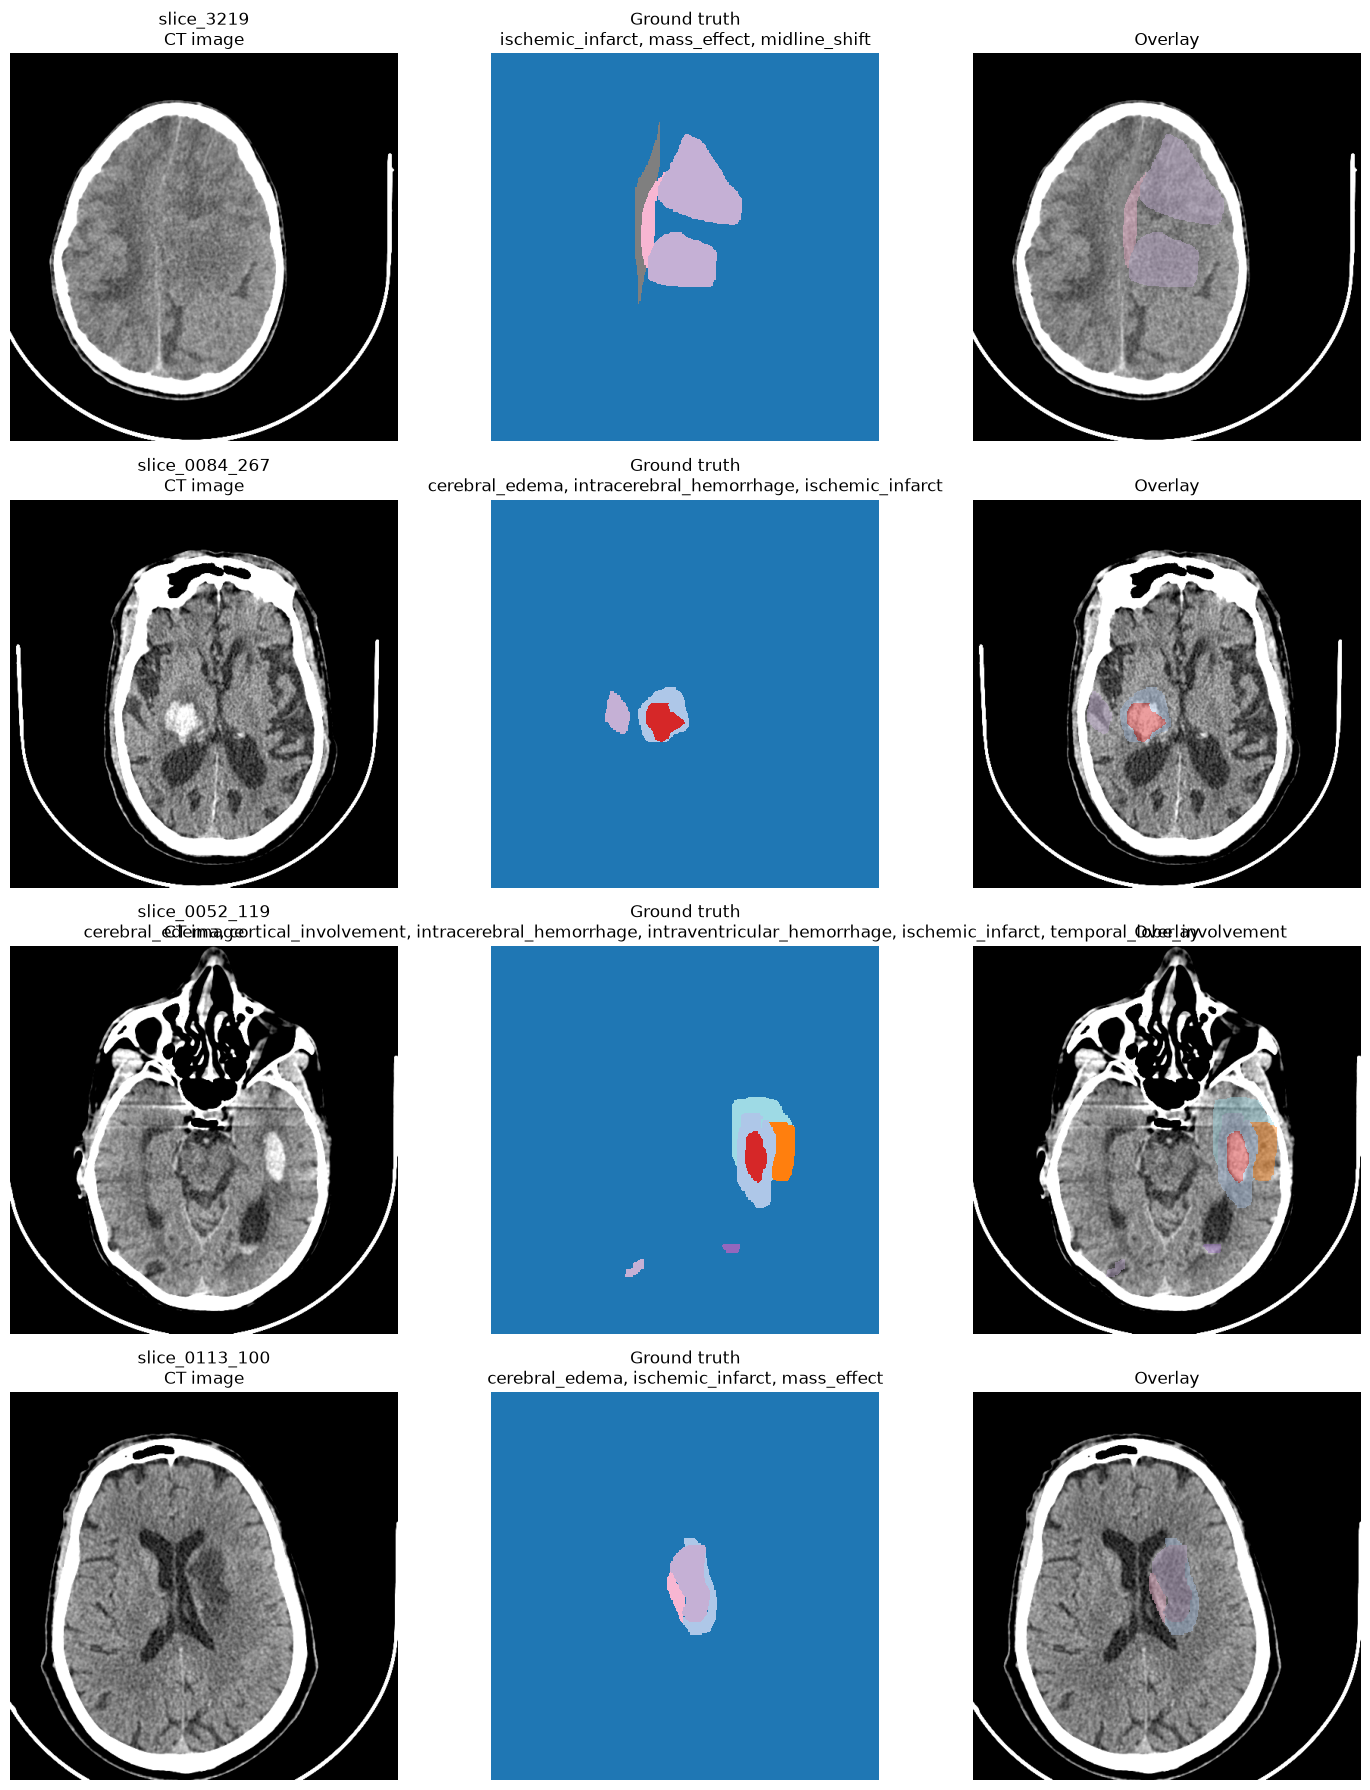

In [11]:
def show_samples(samples: Sequence[Sample], n: int = 4) -> None:
    if not samples:
        print("No samples available.")
        return

    chosen = random.sample(list(samples), k=min(n, len(samples)))
    cmap = plt.get_cmap("tab20", CFG.num_classes)
    norm = BoundaryNorm(np.arange(-0.5, CFG.num_classes + 0.5), cmap.N)

    figure, axes = plt.subplots(
        len(chosen), 3, figsize=(15, 4.5 * len(chosen)), squeeze=False
    )

    for row, sample in enumerate(chosen):
        image = read_image(sample.image_path)
        mask = normalize_multiclass_mask(
            read_mask(sample.mask_path),
            ALLOWED_CLASS_IDS,
        )

        image_cmap = "gray" if image.ndim == 2 else None
        overlay = np.ma.masked_where(mask == 0, mask)
        labels = [
            CLASS_NAMES[int(class_id)]
            for class_id in np.unique(mask)
            if int(class_id) != 0
        ]

        axes[row, 0].imshow(image, cmap=image_cmap)
        axes[row, 0].set_title(f"{sample.sample_id}\nCT image")

        axes[row, 1].imshow(mask, cmap=cmap, norm=norm, interpolation="nearest")
        axes[row, 1].set_title(
            "Ground truth\n" + (", ".join(labels) if labels else "No foreground")
        )

        axes[row, 2].imshow(image, cmap=image_cmap)
        axes[row, 2].imshow(
            overlay, cmap=cmap, norm=norm, alpha=0.45, interpolation="nearest"
        )
        axes[row, 2].set_title("Overlay")

        for axis in axes[row]:
            axis.axis("off")

    plt.tight_layout()
    plt.show()


show_samples(splits["train"], n=4)

## 11. Build data-driven class-aware sampling and cropping policies

In [12]:
TRAIN_PIXEL_COUNTS = {
    int(row.class_id): int(row.pixel_count)
    for row in train_class_report.itertuples()
}

TRAIN_SAMPLE_COUNTS = {
    int(row.class_id): int(row.samples_with_class)
    for row in train_class_report.itertuples()
}

TRAIN_AVERAGE_PIXELS = {
    int(row.class_id): float(row.average_pixels_when_present)
    for row in train_class_report.itertuples()
}

represented_foreground_counts = [
    count
    for class_id, count in TRAIN_SAMPLE_COUNTS.items()
    if class_id != 0 and count > 0
]

REFERENCE_SAMPLE_COUNT = max(represented_foreground_counts, default=1)


def class_sampling_multiplier(class_id: int) -> float:
    if class_id == 0:
        return CFG.background_only_sample_weight

    count = TRAIN_SAMPLE_COUNTS.get(class_id, 0)
    if count <= 0:
        return 0.0

    multiplier = math.sqrt(REFERENCE_SAMPLE_COUNT / count)
    return float(np.clip(multiplier, 1.0, CFG.max_sampling_multiplier))


CLASS_SAMPLING_MULTIPLIERS = {
    class_id: class_sampling_multiplier(class_id)
    for class_id in sorted(ALLOWED_CLASS_IDS)
}


def choose_crop_size(class_id: int) -> int:
    average_area = TRAIN_AVERAGE_PIXELS.get(class_id, 0.0)

    if average_area <= 2_000:
        crop_size = CFG.minimum_crop_size
    elif average_area <= 8_000:
        crop_size = CFG.image_size
    else:
        crop_size = CFG.maximum_crop_size

    crop_size = max(CFG.minimum_crop_size, min(crop_size, CFG.maximum_crop_size))
    return int(math.ceil(crop_size / 16) * 16)


policy_report = pd.DataFrame(
    [
        {
            "class_id": class_id,
            "class_name": CLASS_NAMES[class_id],
            "training_samples": TRAIN_SAMPLE_COUNTS.get(class_id, 0),
            "training_pixels": TRAIN_PIXEL_COUNTS.get(class_id, 0),
            "average_pixels_when_present": TRAIN_AVERAGE_PIXELS.get(class_id, 0.0),
            "sampling_multiplier": CLASS_SAMPLING_MULTIPLIERS[class_id],
            "target_crop_size": (
                choose_crop_size(class_id) if class_id != 0 else None
            ),
        }
        for class_id in sorted(ALLOWED_CLASS_IDS)
    ]
)

display(policy_report.round(4))

,class_id,class_name,training_samples,training_pixels,average_pixels_when_present,sampling_multiplier,target_crop_size
0,0,background,658,168788184,256516.9970,0.6000,NaN
1,1,cerebral_edema,194,985234,5078.5258,1.1688,256.0
2,2,cortical_involvement,39,55847,1431.9744,2.6067,192.0
3,3,hemorrhagic_transformation,24,45881,1911.7083,3.3229,192.0
4,4,hyperdense_artery_sign,0,0,0.0000,0.0000,192.0
5,5,intracerebral_hemorrhage,162,337032,2080.4444,1.2790,256.0
6,6,intraventricular_hemorrhage,58,103272,1780.5517,2.1375,192.0
7,7,ischemic_infarct,265,874604,3300.3925,1.0000,256.0
8,8,large_lesion_1_3_mca_territory,19,362681,19088.4737,3.7346,320.0
9,9,large_vessel_occlusion,23,209372,9103.1304,3.3944,320.0


In [13]:
def build_sample_metadata(samples: Sequence[Sample]) -> List[Dict[str, Any]]:
    metadata = []

    for index, sample in enumerate(tqdm(samples, desc="Building sample metadata")):
        mask = normalize_multiclass_mask(
            read_mask(sample.mask_path),
            ALLOWED_CLASS_IDS,
        )

        classes_present = tuple(
            int(class_id)
            for class_id in np.unique(mask)
            if int(class_id) != 0
        )

        metadata.append(
            {
                "index": index,
                "sample_id": sample.sample_id,
                "patient_id": sample.patient_id,
                "classes_present": classes_present,
            }
        )

    return metadata


def build_class_aware_sampler(
    metadata: List[Dict[str, Any]],
) -> Tuple[WeightedRandomSampler, np.ndarray]:
    patient_slice_counts = Counter(record["patient_id"] for record in metadata)
    median_patient_slices = float(np.median(list(patient_slice_counts.values())))

    sample_weights: List[float] = []

    for record in metadata:
        classes_present = record["classes_present"]

        if classes_present:
            class_weight = max(
                CLASS_SAMPLING_MULTIPLIERS.get(class_id, 1.0)
                for class_id in classes_present
            )
        else:
            class_weight = CFG.background_only_sample_weight

        patient_count = patient_slice_counts[record["patient_id"]]
        patient_adjustment = np.clip(
            median_patient_slices / max(patient_count, 1),
            0.25,
            4.0,
        )

        sample_weights.append(float(class_weight * patient_adjustment))

    weights = np.asarray(sample_weights, dtype=np.float64)
    weights /= max(weights.mean(), 1e-8)
    weights = np.clip(weights, 0.15, CFG.max_sampling_multiplier)

    sampler = WeightedRandomSampler(
        weights=torch.as_tensor(weights, dtype=torch.double),
        num_samples=len(weights),
        replacement=True,
    )

    return sampler, weights


train_metadata = build_sample_metadata(splits["train"])

if CFG.use_class_aware_sampling:
    train_sampler, train_sample_weights = build_class_aware_sampler(train_metadata)
    print(
        "Sampler weight range:",
        float(train_sample_weights.min()),
        "to",
        float(train_sample_weights.max()),
    )
else:
    train_sampler = None

Building sample metadata:   0%|          | 0/658 [00:00<?, ?it/s]

Sampler weight range: 0.4049105375455592 to 4.049105375455592


## 12. Class-centred crop and CT-safe augmentation

In [14]:
def select_target_class(mask: np.ndarray) -> Optional[int]:
    classes_present = [
        int(class_id)
        for class_id in np.unique(mask)
        if int(class_id) != 0
        and TRAIN_SAMPLE_COUNTS.get(int(class_id), 0) > 0
    ]

    if not classes_present:
        return None

    weights = [
        CLASS_SAMPLING_MULTIPLIERS.get(class_id, 1.0)
        for class_id in classes_present
    ]

    return int(random.choices(classes_present, weights=weights, k=1)[0])


def pad_for_crop(
    image: np.ndarray,
    mask: np.ndarray,
    crop_size: int,
) -> Tuple[np.ndarray, np.ndarray]:
    height, width = mask.shape
    pad_height = max(0, crop_size - height)
    pad_width = max(0, crop_size - width)

    top = pad_height // 2
    bottom = pad_height - top
    left = pad_width // 2
    right = pad_width - left

    if pad_height or pad_width:
        image = cv2.copyMakeBorder(
            image,
            top,
            bottom,
            left,
            right,
            borderType=cv2.BORDER_REFLECT_101,
        )
        mask = cv2.copyMakeBorder(
            mask,
            top,
            bottom,
            left,
            right,
            borderType=cv2.BORDER_CONSTANT,
            value=0,
        )

    return image, mask


def crop_around_target_class(
    image: np.ndarray,
    mask: np.ndarray,
    target_class_id: int,
    crop_size: int,
    jitter_fraction: float = 0.15,
) -> Tuple[np.ndarray, np.ndarray]:
    image, mask = pad_for_crop(image, mask, crop_size)

    coordinates = np.argwhere(mask == target_class_id)
    if len(coordinates) == 0:
        return image, mask

    center_y, center_x = coordinates[random.randrange(len(coordinates))]
    maximum_jitter = int(crop_size * jitter_fraction)

    center_y += random.randint(-maximum_jitter, maximum_jitter)
    center_x += random.randint(-maximum_jitter, maximum_jitter)

    height, width = mask.shape
    top = max(0, min(int(center_y - crop_size // 2), height - crop_size))
    left = max(0, min(int(center_x - crop_size // 2), width - crop_size))

    return (
        image[top : top + crop_size, left : left + crop_size],
        mask[top : top + crop_size, left : left + crop_size],
    )


train_transform = A.Compose(
    [
        A.Resize(
            CFG.image_size,
            CFG.image_size,
            interpolation=cv2.INTER_LINEAR,
            mask_interpolation=cv2.INTER_NEAREST,
        ),
        A.HorizontalFlip(p=0.50),
        A.Affine(
            scale=(0.95, 1.05),
            translate_percent=(-0.03, 0.03),
            rotate=(-7, 7),
            shear=(-2, 2),
            interpolation=cv2.INTER_LINEAR,
            mask_interpolation=cv2.INTER_NEAREST,
            border_mode=cv2.BORDER_CONSTANT,
            fill=0,
            fill_mask=0,
            p=0.65,
        ),
        A.OneOf(
            [
                A.RandomBrightnessContrast(
                    brightness_limit=0.08,
                    contrast_limit=0.12,
                    p=1.0,
                ),
                A.RandomGamma(gamma_limit=(92, 108), p=1.0),
                A.CLAHE(
                    clip_limit=(1.0, 2.0),
                    tile_grid_size=(8, 8),
                    p=1.0,
                ),
            ],
            p=0.45,
        ),
        A.OneOf(
            [
                A.GaussNoise(p=1.0),
                A.GaussianBlur(blur_limit=(3, 3), p=1.0),
            ],
            p=0.12,
        ),
        A.Normalize(
            mean=(0.5, 0.5, 0.5),
            std=(0.5, 0.5, 0.5),
            max_pixel_value=255.0,
        ),
        ToTensorV2(),
    ],
    mask_interpolation=cv2.INTER_NEAREST,
    seed=CFG.seed,
)


evaluation_transform = A.Compose(
    [
        A.Resize(
            CFG.image_size,
            CFG.image_size,
            interpolation=cv2.INTER_LINEAR,
            mask_interpolation=cv2.INTER_NEAREST,
        ),
        A.Normalize(
            mean=(0.5, 0.5, 0.5),
            std=(0.5, 0.5, 0.5),
            max_pixel_value=255.0,
        ),
        ToTensorV2(),
    ],
    mask_interpolation=cv2.INTER_NEAREST,
)

Horizontal flipping is appropriate only when your class IDs do not encode left-versus-right laterality. Remove it if laterality becomes clinically meaningful.

## 13. PyTorch dataset and data loaders

In [15]:
class StrokeSegmentationDataset(Dataset):
    def __init__(
        self,
        samples: Sequence[Sample],
        transform: Optional[A.Compose],
        training: bool,
    ) -> None:
        self.samples = list(samples)
        self.transform = transform
        self.training = training

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, index: int) -> Dict[str, Any]:
        sample = self.samples[index]

        image = read_image(sample.image_path)
        mask = normalize_multiclass_mask(
            read_mask(sample.mask_path),
            ALLOWED_CLASS_IDS,
        )

        if image.shape[:2] != mask.shape[:2]:
            raise ValueError(
                f"Shape mismatch for {sample.sample_id}: "
                f"image={image.shape}, mask={mask.shape}"
            )

        target_class_id: Optional[int] = None

        if self.training and CFG.use_class_centered_crops:
            target_class_id = select_target_class(mask)

            if (
                target_class_id is not None
                and random.random() < CFG.class_crop_probability
            ):
                crop_size = choose_crop_size(target_class_id)
                image, mask = crop_around_target_class(
                    image=image,
                    mask=mask,
                    target_class_id=target_class_id,
                    crop_size=crop_size,
                )

        if image.ndim == 2:
            image = np.repeat(image[..., None], CFG.input_channels, axis=2)
        elif image.ndim == 3 and image.shape[2] == 1:
            image = np.repeat(image, CFG.input_channels, axis=2)

        if image.ndim != 3 or image.shape[2] != CFG.input_channels:
            raise ValueError(
                f"Expected {CFG.input_channels} image channels after conversion, "
                f"received {image.shape} for {sample.sample_id}."
            )

        transformed = self.transform(image=image, mask=mask)
        image_tensor = transformed["image"].float()
        mask_tensor = transformed["mask"].long()

        return {
            "image": image_tensor,
            "mask": mask_tensor,
            "sample_id": sample.sample_id,
            "patient_id": sample.patient_id,
            "target_class_id": -1 if target_class_id is None else target_class_id,
        }


train_dataset = StrokeSegmentationDataset(
    splits["train"], transform=train_transform, training=True
)
val_dataset = StrokeSegmentationDataset(
    splits["val"], transform=evaluation_transform, training=False
)
test_dataset = StrokeSegmentationDataset(
    splits["test"], transform=evaluation_transform, training=False
)


def seed_worker(worker_id: int) -> None:
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)


generator = torch.Generator()
generator.manual_seed(CFG.seed)

persistent_workers = CFG.persistent_workers and CFG.num_workers > 0

train_loader = DataLoader(
    train_dataset,
    batch_size=CFG.batch_size,
    sampler=train_sampler,
    shuffle=train_sampler is None,
    num_workers=CFG.num_workers,
    pin_memory=CFG.pin_memory,
    persistent_workers=persistent_workers,
    worker_init_fn=seed_worker,
    generator=generator,
    drop_last=False,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CFG.batch_size,
    shuffle=False,
    num_workers=CFG.num_workers,
    pin_memory=CFG.pin_memory,
    persistent_workers=persistent_workers,
    worker_init_fn=seed_worker,
    generator=generator,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CFG.batch_size,
    shuffle=False,
    num_workers=CFG.num_workers,
    pin_memory=CFG.pin_memory,
    persistent_workers=persistent_workers,
    worker_init_fn=seed_worker,
    generator=generator,
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 165
Validation batches: 36
Test batches: 36


## 14. Verify the effective augmented class distribution

In [16]:
def inspect_augmented_loader(
    loader: DataLoader,
    number_of_batches: int = 50,
) -> pd.DataFrame:
    class_sample_counts = Counter()
    class_pixel_counts = Counter()
    processed_samples = 0

    for batch_index, batch in enumerate(loader):
        if batch_index >= number_of_batches:
            break

        masks = batch["mask"].cpu().numpy()

        for mask in masks:
            processed_samples += 1
            class_ids, pixel_counts = np.unique(mask, return_counts=True)

            for class_id, pixel_count in zip(class_ids, pixel_counts):
                class_id = int(class_id)
                class_sample_counts[class_id] += 1
                class_pixel_counts[class_id] += int(pixel_count)

    total_pixels = sum(class_pixel_counts.values())

    return pd.DataFrame(
        [
            {
                "class_id": class_id,
                "class_name": CLASS_NAMES[class_id],
                "augmented_samples_with_class": class_sample_counts[class_id],
                "augmented_sample_presence_pct": (
                    100 * class_sample_counts[class_id] / max(processed_samples, 1)
                ),
                "augmented_pixel_pct": (
                    100 * class_pixel_counts[class_id] / max(total_pixels, 1)
                ),
            }
            for class_id in sorted(ALLOWED_CLASS_IDS)
        ]
    )


augmented_distribution = inspect_augmented_loader(train_loader, number_of_batches=50)
display(augmented_distribution.round(4))

,class_id,class_name,augmented_samples_with_class,augmented_sample_presence_pct,augmented_pixel_pct
0,0,background,200,100.0,89.9232
1,1,cerebral_edema,83,41.5,2.7881
2,2,cortical_involvement,20,10.0,0.1466
3,3,hemorrhagic_transformation,17,8.5,0.2489
4,4,hyperdense_artery_sign,0,0.0,0.0000
5,5,intracerebral_hemorrhage,65,32.5,0.8410
6,6,intraventricular_hemorrhage,32,16.0,0.4333
7,7,ischemic_infarct,74,37.0,1.2048
8,8,large_lesion_1_3_mca_territory,13,6.5,0.9596
9,9,large_vessel_occlusion,21,10.5,0.9179


## 15. Build BRIDGE-Net (biomarker-aware multi-scale relational architecture)


In [17]:
def load_matching_warmstart_weights(
    model: nn.Module,
    checkpoint_path: Path,
) -> Dict[str, int]:
    """Load parameters whose names and tensor shapes match."""
    try:
        checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=True)
    except TypeError:
        checkpoint = torch.load(checkpoint_path, map_location="cpu")

    if isinstance(checkpoint, dict):
        state = checkpoint.get("model_state_dict") or checkpoint.get("state_dict") or checkpoint
    else:
        raise TypeError("Warm-start checkpoint must contain a state dictionary.")

    state = {
        key.removeprefix("module."): value
        for key, value in state.items()
        if torch.is_tensor(value)
    }
    current_state = model.state_dict()
    matching = {
        key: value
        for key, value in state.items()
        if key in current_state and current_state[key].shape == value.shape
    }
    result = model.load_state_dict(matching, strict=False)
    return {
        "loaded_tensors": len(matching),
        "missing_tensors": len(result.missing_keys),
        "unexpected_tensors": len(result.unexpected_keys),
    }


model = BRIDGENet(
    input_channels=CFG.input_channels,
    num_classes=CFG.num_classes,
    channels=CFG.unet_channels,
    dropout=CFG.unet_dropout,
    maximum_groups=CFG.group_norm_max_groups,
    relation_dim=CFG.bridge_relation_dim,
    num_heads=CFG.bridge_num_heads,
    relation_grid_size=CFG.bridge_relation_grid_size,
    rarity_gate_strength=CFG.bridge_rarity_gate_strength,
    common_source_bias=CFG.bridge_common_source_bias,
    residual_head_weight=CFG.bridge_residual_head_weight,
).to(DEVICE)

# Use only the TRAIN split to derive long-tail frequency priors.
foreground_train_counts = [
    float(TRAIN_SAMPLE_COUNTS.get(class_id, 0))
    for class_id in range(1, CFG.num_classes)
]
model.set_class_frequencies(foreground_train_counts)

if CFG.warmstart_checkpoint:
    warmstart_path = Path(CFG.warmstart_checkpoint)
    if not warmstart_path.exists():
        raise FileNotFoundError(f"Warm-start checkpoint not found: {warmstart_path}")
    warmstart_report = load_matching_warmstart_weights(model, warmstart_path)
    print("Warm-start report:", warmstart_report)

trainable_parameters = sum(
    parameter.numel() for parameter in model.parameters() if parameter.requires_grad
)

print("Model:", model.__class__.__name__)
print("Trainable parameters:", f"{trainable_parameters:,}")
print("Image-backbone channels:", CFG.unet_channels)
print("Relation dimension:", CFG.bridge_relation_dim)
print("Relational scales:", CFG.bridge_scale_names)
print("Relational scale grids:", (
    CFG.bridge_relation_grid_size,
    max(4, CFG.bridge_relation_grid_size // 2),
    max(2, CFG.bridge_relation_grid_size // 4),
))
print("Foreground training sample counts:", foreground_train_counts)
print("Rarity scores:", model.relational_transfer.rarity_scores.detach().cpu().numpy())


Model: BRIDGENet
Trainable parameters: 8,191,828
Image-backbone channels: (32, 64, 128, 256, 512)
Relation dimension: 128
Relational scales: ('local_1_2', 'regional_1_4', 'global_1_8')
Relational scale grids: (32, 16, 8)
Foreground training sample counts: [194.0, 39.0, 24.0, 0.0, 162.0, 58.0, 265.0, 19.0, 23.0, 88.0, 53.0, 58.0, 4.0, 36.0, 31.0]
Rarity scores: [0.05560964 0.3393244  0.42350173 1.         0.08771318 0.26971608
 0.         0.46346658 0.4308129  0.19608855 0.28557593 0.26971608
 0.71175086 0.35328728 0.37928927]


## 16. Verify the BRIDGE-Net output contract


In [18]:
def extract_logits(model_output: Any) -> torch.Tensor:
    if isinstance(model_output, torch.Tensor):
        return model_output

    if isinstance(model_output, dict):
        for key in ("out", "logits"):
            if key in model_output:
                return model_output[key]
        raise KeyError("Model-output dictionary has no 'out' or 'logits' key.")

    if isinstance(model_output, (tuple, list)):
        if not model_output:
            raise ValueError("Model returned an empty tuple/list.")
        return model_output[0]

    raise TypeError(f"Unsupported model-output type: {type(model_output)}")


batch = next(iter(train_loader))
verification_images = batch["image"][:1].to(DEVICE)

model.eval()
with torch.no_grad():
    verification_output = model(verification_images)
    verification_logits = extract_logits(verification_output)

print("Input shape:", tuple(verification_images.shape))
print("Output shape:", tuple(verification_logits.shape))

assert verification_logits.ndim == 4
assert verification_logits.shape[1] == CFG.num_classes
assert verification_logits.shape[-2:] == verification_images.shape[-2:]

model.train()

Input shape: (1, 3, 256, 256)
Output shape: (1, 16, 256, 256)


BRIDGENet(
  (encoder1): DoubleConv(
    (block): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): GroupNorm(8, 32, eps=1e-05, affine=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): GroupNorm(8, 32, eps=1e-05, affine=True)
      (5): ReLU(inplace=True)
    )
  )
  (encoder2): DownBlock(
    (block): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): DoubleConv(
        (block): Sequential(
          (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): GroupNorm(8, 64, eps=1e-05, affine=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (4): GroupNorm(8, 64, eps=1e-05, affine=True)
          (5): ReLU(inplace=True)
        )
      )
    )
  )
  (en

## 17. Weighted cross-entropy and multiclass Dice loss

In [19]:
def calculate_class_weights_from_training(
    train_report: pd.DataFrame,
) -> torch.Tensor:
    counts = (
        train_report.sort_values("class_id")["pixel_count"]
        .to_numpy(dtype=np.float64)
    )

    weights = np.zeros_like(counts, dtype=np.float64)
    represented = counts > 0

    if represented.any():
        frequencies = counts[represented] / counts[represented].sum()
        represented_weights = np.sqrt(1.0 / frequencies)
        represented_weights /= represented_weights.mean()
        represented_weights = np.clip(
            represented_weights,
            CFG.class_weight_min,
            CFG.class_weight_max,
        )
        weights[represented] = represented_weights

    # A globally missing training class receives no CE gradient.
    weights[~represented] = 0.0

    return torch.tensor(weights, dtype=torch.float32, device=DEVICE)


class SoftDiceLoss(nn.Module):
    def __init__(
        self,
        num_classes: int,
        active_class_ids: Sequence[int],
        ignore_index: Optional[int] = None,
        smooth: float = 1e-5,
    ) -> None:
        super().__init__()
        self.num_classes = num_classes
        self.active_class_ids = tuple(int(value) for value in active_class_ids)
        self.ignore_index = ignore_index
        self.smooth = smooth

    def forward(
        self,
        logits: torch.Tensor,
        targets: torch.Tensor,
    ) -> torch.Tensor:
        targets = targets.long()

        if self.ignore_index is not None:
            valid_mask = targets != self.ignore_index
            safe_targets = targets.clone()
            safe_targets[~valid_mask] = 0
        else:
            valid_mask = torch.ones_like(targets, dtype=torch.bool)
            safe_targets = targets

        valid_values = safe_targets[valid_mask]
        if valid_values.numel():
            minimum = int(valid_values.min())
            maximum = int(valid_values.max())
            if minimum < 0 or maximum >= self.num_classes:
                raise ValueError(
                    f"Target IDs must be in 0–{self.num_classes - 1}; "
                    f"found {minimum}–{maximum}."
                )

        probabilities = torch.softmax(logits, dim=1)
        one_hot = F.one_hot(
            safe_targets,
            num_classes=self.num_classes,
        ).permute(0, 3, 1, 2).float()

        valid_mask = valid_mask.unsqueeze(1).float()
        probabilities = probabilities * valid_mask
        one_hot = one_hot * valid_mask

        active = torch.tensor(
            self.active_class_ids,
            dtype=torch.long,
            device=logits.device,
        )

        probabilities = probabilities.index_select(1, active)
        one_hot = one_hot.index_select(1, active)

        dimensions = (0, 2, 3)
        intersection = torch.sum(probabilities * one_hot, dim=dimensions)
        denominator = torch.sum(probabilities + one_hot, dim=dimensions)
        dice = (2.0 * intersection + self.smooth) / (
            denominator + self.smooth
        )

        return 1.0 - dice.mean()


class_weights = calculate_class_weights_from_training(train_class_report)

active_foreground_class_ids = [
    class_id
    for class_id in range(1, CFG.num_classes)
    if TRAIN_PIXEL_COUNTS.get(class_id, 0) > 0
]

print("Class weights:", class_weights.detach().cpu().numpy())
print("Active Dice classes:", active_foreground_class_ids)

cross_entropy_loss = nn.CrossEntropyLoss(
    weight=class_weights,
    ignore_index=CFG.ignore_index,
)

dice_loss_function = SoftDiceLoss(
    num_classes=CFG.num_classes,
    active_class_ids=active_foreground_class_ids,
    ignore_index=CFG.ignore_index,
)


def segmentation_loss(
    logits: torch.Tensor,
    targets: torch.Tensor,
) -> Tuple[torch.Tensor, Dict[str, float]]:
    ce_loss = cross_entropy_loss(logits, targets)
    dice_loss = dice_loss_function(logits, targets)

    total_loss = (
        CFG.ce_weight * ce_loss
        + CFG.dice_weight * dice_loss
    )

    return total_loss, {
        "ce_loss": float(ce_loss.detach().item()),
        "dice_loss": float(dice_loss.detach().item()),
    }

Class weights: [0.1        0.33582792 1.4105438  1.5562167  0.         0.5741838
 1.037278   0.35643536 0.5535082  0.728496   0.613795   0.9535702
 0.93955815 3.         1.0415328  1.218044  ]
Active Dice classes: [1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]


## 18. Multiclass segmentation metrics

In [20]:
def multiclass_confusion_matrix(
    predictions: torch.Tensor,
    targets: torch.Tensor,
    num_classes: int,
    ignore_index: Optional[int] = None,
) -> torch.Tensor:
    if predictions.ndim == 4:
        predictions = torch.argmax(predictions, dim=1)

    predictions = predictions.long().reshape(-1)
    targets = targets.long().reshape(-1)

    if ignore_index is not None:
        valid = targets != ignore_index
        predictions = predictions[valid]
        targets = targets[valid]

    valid = (
        (targets >= 0)
        & (targets < num_classes)
        & (predictions >= 0)
        & (predictions < num_classes)
    )

    if not bool(valid.all()):
        raise ValueError("Predictions or targets contain invalid class IDs.")

    encoded = targets * num_classes + predictions
    return torch.bincount(
        encoded,
        minlength=num_classes**2,
    ).reshape(num_classes, num_classes)


def safe_divide(numerator: float, denominator: float) -> float:
    return float(numerator / denominator) if denominator else float("nan")


def metrics_from_confusion_matrix(
    confusion_matrix: torch.Tensor,
    include_background: bool = False,
) -> Tuple[pd.DataFrame, Dict[str, float]]:
    matrix = confusion_matrix.detach().cpu().numpy().astype(np.float64)
    total = matrix.sum()
    first_class = 0 if include_background else 1

    rows: List[Dict[str, Any]] = []

    for class_id in range(first_class, CFG.num_classes):
        true_positive = matrix[class_id, class_id]
        false_negative = matrix[class_id, :].sum() - true_positive
        false_positive = matrix[:, class_id].sum() - true_positive
        true_negative = total - true_positive - false_positive - false_negative

        rows.append(
            {
                "class_id": class_id,
                "class_name": CLASS_NAMES[class_id],
                "support_pixels": int(true_positive + false_negative),
                "predicted_pixels": int(true_positive + false_positive),
                "tp": int(true_positive),
                "fp": int(false_positive),
                "fn": int(false_negative),
                "tn": int(true_negative),
                "dice": safe_divide(
                    2 * true_positive,
                    2 * true_positive + false_positive + false_negative,
                ),
                "iou": safe_divide(
                    true_positive,
                    true_positive + false_positive + false_negative,
                ),
                "precision": safe_divide(
                    true_positive,
                    true_positive + false_positive,
                ),
                "recall": safe_divide(
                    true_positive,
                    true_positive + false_negative,
                ),
                "specificity": safe_divide(
                    true_negative,
                    true_negative + false_positive,
                ),
            }
        )

    report = pd.DataFrame(rows)

    represented = report["support_pixels"] > 0
    represented_report = report.loc[represented]

    summary = {
        "mean_foreground_dice": float(
            represented_report["dice"].mean(skipna=True)
        ),
        "mean_foreground_iou": float(
            represented_report["iou"].mean(skipna=True)
        ),
        "mean_foreground_precision": float(
            represented_report["precision"].mean(skipna=True)
        ),
        "mean_foreground_recall": float(
            represented_report["recall"].mean(skipna=True)
        ),
    }

    valid_weighted = represented & report["dice"].notna()
    if valid_weighted.any():
        summary["weighted_foreground_dice"] = float(
            np.average(
                report.loc[valid_weighted, "dice"],
                weights=report.loc[valid_weighted, "support_pixels"],
            )
        )
    else:
        summary["weighted_foreground_dice"] = float("nan")

    return report, summary

## 19. HD95 boundary metric

In [21]:
def hd95_binary(
    prediction: np.ndarray,
    target: np.ndarray,
    spacing: Optional[Sequence[float]] = None,
    both_empty_value: float = np.nan,
    one_empty_value: float = np.inf,
) -> float:
    prediction = np.asarray(prediction, dtype=bool)
    target = np.asarray(target, dtype=bool)

    if prediction.shape != target.shape:
        raise ValueError(
            f"Prediction-target shape mismatch: "
            f"{prediction.shape} versus {target.shape}"
        )

    if not prediction.any() and not target.any():
        return float(both_empty_value)

    if not prediction.any() or not target.any():
        return float(one_empty_value)

    prediction_border = prediction ^ binary_erosion(
        prediction, border_value=0
    )
    target_border = target ^ binary_erosion(target, border_value=0)

    target_distance = distance_transform_edt(
        ~target_border,
        sampling=spacing,
    )
    prediction_distance = distance_transform_edt(
        ~prediction_border,
        sampling=spacing,
    )

    distances = np.concatenate(
        [
            target_distance[prediction_border],
            prediction_distance[target_border],
        ]
    )

    return float(np.percentile(distances, 95))

## 20. AdamW, step-based warmup/cosine scheduler, and AMP

In [22]:
def get_optimizer_parameter_groups(
    model: nn.Module,
    weight_decay: float,
) -> List[Dict[str, Any]]:
    decay_parameters = []
    no_decay_parameters = []

    for parameter_name, parameter in model.named_parameters():
        if not parameter.requires_grad:
            continue

        lower_name = parameter_name.lower()
        no_decay = (
            lower_name.endswith(".bias")
            or parameter.ndim <= 1
            or any(
                keyword in lower_name
                for keyword in ("norm", "bn", "batchnorm", "layernorm")
            )
        )

        if no_decay:
            no_decay_parameters.append(parameter)
        else:
            decay_parameters.append(parameter)

    return [
        {"params": decay_parameters, "weight_decay": weight_decay},
        {"params": no_decay_parameters, "weight_decay": 0.0},
    ]


optimizer = torch.optim.AdamW(
    get_optimizer_parameter_groups(model, CFG.weight_decay),
    lr=CFG.learning_rate,
    betas=(0.9, 0.999),
    eps=1e-8,
)

steps_per_epoch = len(train_loader)
total_training_steps = max(1, CFG.epochs * steps_per_epoch)
warmup_steps = min(
    CFG.warmup_epochs * steps_per_epoch,
    max(0, total_training_steps - 1),
)
cosine_steps = max(1, total_training_steps - warmup_steps)
minimum_lr_ratio = CFG.min_learning_rate / CFG.learning_rate


def warmup_cosine_lr_lambda(current_step: int) -> float:
    if warmup_steps > 0 and current_step < warmup_steps:
        return max((current_step + 1) / warmup_steps, 1e-8)

    progress = (current_step - warmup_steps) / cosine_steps
    progress = float(np.clip(progress, 0.0, 1.0))
    cosine = 0.5 * (1.0 + math.cos(math.pi * progress))

    return minimum_lr_ratio + (1.0 - minimum_lr_ratio) * cosine


scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=warmup_cosine_lr_lambda,
)

AMP_ENABLED = bool(
    CFG.amp
    and DEVICE.type == "cuda"
    and torch.cuda.is_available()
)

try:
    scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)
except (AttributeError, TypeError):
    scaler = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)

print("Steps per epoch:", steps_per_epoch)
print("Total training steps:", total_training_steps)
print("Warmup steps:", warmup_steps)
print("AMP enabled:", scaler.is_enabled())

Steps per epoch: 165
Total training steps: 24750
Warmup steps: 825
AMP enabled: True


## 21. Training and validation epoch function

In [23]:
def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    training: bool,
    optimizer: Optional[torch.optim.Optimizer] = None,
    scheduler: Optional[Any] = None,
    scaler: Optional[Any] = None,
) -> Dict[str, object]:
    if training and optimizer is None:
        raise ValueError("An optimizer is required when training=True.")

    model.train(training)

    total_loss = 0.0
    total_ce_loss = 0.0
    total_dice_loss = 0.0
    total_samples = 0

    epoch_confusion = torch.zeros(
        CFG.num_classes,
        CFG.num_classes,
        dtype=torch.int64,
    )

    amp_enabled = bool(
        scaler is not None
        and scaler.is_enabled()
        and DEVICE.type == "cuda"
    )

    progress = tqdm(
        loader,
        desc="train" if training else "validate",
        leave=False,
    )

    for batch in progress:
        images = batch["image"].to(
            DEVICE,
            non_blocking=True,
        ).float()

        targets = batch["mask"].to(
            DEVICE,
            non_blocking=True,
        ).long()

        batch_size = images.size(0)

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            with torch.autocast(
                device_type=DEVICE.type,
                dtype=torch.float16 if DEVICE.type == "cuda" else torch.bfloat16,
                enabled=amp_enabled,
            ):
                model_output = model(images)
                logits = extract_logits(model_output)

                if logits.shape[-2:] != targets.shape[-2:]:
                    logits = F.interpolate(
                        logits,
                        size=targets.shape[-2:],
                        mode="bilinear",
                        align_corners=False,
                    )

                loss, loss_parts = segmentation_loss(logits, targets)

        if not torch.isfinite(loss):
            raise FloatingPointError(f"Non-finite loss: {loss.item()}")

        optimizer_step_completed = False
        gradient_norm = torch.tensor(float("nan"))

        if training:
            if amp_enabled:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)

                gradient_norm = torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=CFG.gradient_clip_norm,
                )

                previous_scale = scaler.get_scale()
                scaler.step(optimizer)
                scaler.update()
                optimizer_step_completed = scaler.get_scale() >= previous_scale
            else:
                loss.backward()

                gradient_norm = torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=CFG.gradient_clip_norm,
                )

                optimizer.step()
                optimizer_step_completed = True

            if scheduler is not None and optimizer_step_completed:
                scheduler.step()

        predictions = torch.argmax(logits.detach(), dim=1)

        epoch_confusion += multiclass_confusion_matrix(
            predictions=predictions,
            targets=targets,
            num_classes=CFG.num_classes,
            ignore_index=CFG.ignore_index,
        ).cpu()

        total_loss += float(loss.detach().item()) * batch_size
        total_ce_loss += float(loss_parts["ce_loss"]) * batch_size
        total_dice_loss += float(loss_parts["dice_loss"]) * batch_size
        total_samples += batch_size

        postfix = {"loss": f"{loss.detach().item():.4f}"}
        if training:
            postfix["lr"] = f"{optimizer.param_groups[0]['lr']:.2e}"
            postfix["grad"] = f"{float(gradient_norm):.2f}"
        progress.set_postfix(postfix)

    if total_samples == 0:
        raise ValueError("The DataLoader returned no samples.")

    per_class_metrics, summary = metrics_from_confusion_matrix(
        epoch_confusion,
        include_background=False,
    )

    return {
        "loss": total_loss / total_samples,
        "ce_loss": total_ce_loss / total_samples,
        "dice_loss": total_dice_loss / total_samples,
        **summary,
        "learning_rate": (
            optimizer.param_groups[0]["lr"]
            if optimizer is not None
            else float("nan")
        ),
        "per_class_metrics": per_class_metrics,
        "confusion_matrix": epoch_confusion,
    }

## 22. Atomic checkpoints and resume support

In [24]:
def unwrap_model(model: nn.Module) -> nn.Module:
    return model.module if hasattr(model, "module") else model


def save_checkpoint_atomic(
    payload: Dict[str, object],
    path: Path,
) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    temporary_path = path.with_name(f".{path.name}.{os.getpid()}.tmp")

    try:
        with temporary_path.open("wb") as file:
            torch.save(payload, file)
            file.flush()
            os.fsync(file.fileno())

        os.replace(temporary_path, path)
    finally:
        if temporary_path.exists():
            temporary_path.unlink(missing_ok=True)


def checkpoint_payload(
    epoch: int,
    best_val_dice: float,
    history: List[Dict[str, float]],
    best_epoch: Optional[int] = None,
    extra: Optional[Dict[str, Any]] = None,
) -> Dict[str, object]:
    return {
        "checkpoint_format_version": 1,
        "architecture": "UNet",
        "epoch": int(epoch),
        "next_epoch": int(epoch) + 1,
        "best_epoch": best_epoch,
        "best_val_dice": float(best_val_dice),
        "model_state_dict": unwrap_model(model).state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "scaler_state_dict": scaler.state_dict(),
        "history": history,
        "config": asdict(CFG),
        "class_names": CLASS_NAMES,
        "architecture_config": {
            "input_channels": CFG.input_channels,
            "num_classes": CFG.num_classes,
            "channels": list(CFG.unet_channels),
            "dropout": CFG.unet_dropout,
            "group_norm_max_groups": CFG.group_norm_max_groups,
        },
        "torch_version": torch.__version__,
        "extra": extra or {},
    }


def move_optimizer_state_to_device(
    optimizer: torch.optim.Optimizer,
    device: torch.device,
) -> None:
    for state in optimizer.state.values():
        for key, value in state.items():
            if torch.is_tensor(value):
                state[key] = value.to(device)


def load_checkpoint(
    path: Path,
    load_optimizer: bool = False,
    strict: bool = True,
) -> Dict[str, object]:
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"Checkpoint not found: {path.resolve()}")

    try:
        checkpoint = torch.load(
            path,
            map_location="cpu",
            weights_only=True,
        )
    except TypeError:
        checkpoint = torch.load(path, map_location="cpu")

    saved_state = {
        key.removeprefix("module."): value
        for key, value in checkpoint["model_state_dict"].items()
    }

    load_result = unwrap_model(model).load_state_dict(
        saved_state,
        strict=strict,
    )
    unwrap_model(model).to(DEVICE)

    if not strict:
        print("Missing keys:", load_result.missing_keys)
        print("Unexpected keys:", load_result.unexpected_keys)

    if load_optimizer:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        move_optimizer_state_to_device(optimizer, DEVICE)

        if checkpoint.get("scheduler_state_dict") is not None:
            scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

        if checkpoint.get("scaler_state_dict") is not None:
            scaler.load_state_dict(checkpoint["scaler_state_dict"])

    print("Loaded checkpoint:", path.resolve())
    print("Completed epoch:", checkpoint.get("epoch"))
    print("Best validation Dice:", checkpoint.get("best_val_dice"))

    return checkpoint

## 23. Train with early stopping, TensorBoard, and CSV logging

In [25]:
best_path = CHECKPOINT_DIR / "best_bridgenet.pt"
last_path = CHECKPOINT_DIR / "last_bridgenet.pt"
history_path = LOG_DIR / "history.csv"
per_class_history_path = LOG_DIR / "per_class_metrics.csv"

writer = SummaryWriter(log_dir=str(LOG_DIR / "tensorboard"))

history: List[Dict[str, float]] = []
best_val_dice = -float("inf")
best_epoch: Optional[int] = None
epochs_without_improvement = 0
start_epoch = 0


def extract_scalar_metrics(metrics: Dict[str, object]) -> Dict[str, float]:
    return {
        key: float(value)
        for key, value in metrics.items()
        if isinstance(value, (int, float, np.integer, np.floating))
    }


def append_per_class_metrics(
    metrics: Dict[str, object],
    epoch_number: int,
    split_name: str,
    output_path: Path,
) -> None:
    report = metrics.get("per_class_metrics")
    if not isinstance(report, pd.DataFrame):
        return

    output = report.copy()
    output.insert(0, "epoch", epoch_number)
    output.insert(1, "split", split_name)

    output.to_csv(
        output_path,
        mode="a",
        header=not output_path.exists(),
        index=False,
    )


def log_per_class_metrics(
    writer: SummaryWriter,
    metrics: Dict[str, object],
    epoch_number: int,
    split_name: str,
) -> None:
    report = metrics.get("per_class_metrics")
    if not isinstance(report, pd.DataFrame):
        return

    for _, row in report.iterrows():
        class_id = int(row["class_id"])
        class_name = str(row["class_name"]).replace(" ", "_")

        for metric_name in ("dice", "iou", "precision", "recall"):
            value = row.get(metric_name, np.nan)
            if pd.notna(value) and np.isfinite(float(value)):
                writer.add_scalar(
                    f"{split_name}_per_class/"
                    f"{metric_name}_{class_id:02d}_{class_name}",
                    float(value),
                    epoch_number,
                )


try:
    for epoch in range(start_epoch, CFG.epochs):
        epoch_number = epoch + 1
        started = time.time()

        train_metrics = run_epoch(
            model=model,
            loader=train_loader,
            training=True,
            optimizer=optimizer,
            scheduler=scheduler,
            scaler=scaler,
        )

        val_metrics = run_epoch(
            model=model,
            loader=val_loader,
            training=False,
            optimizer=None,
            scheduler=None,
            scaler=scaler,
        )

        elapsed_seconds = time.time() - started
        current_learning_rate = float(optimizer.param_groups[0]["lr"])

        row: Dict[str, float] = {
            "epoch": float(epoch_number),
            "learning_rate": current_learning_rate,
            "elapsed_seconds": float(elapsed_seconds),
        }

        row.update(
            {
                f"train_{key}": value
                for key, value in extract_scalar_metrics(train_metrics).items()
            }
        )

        row.update(
            {
                f"val_{key}": value
                for key, value in extract_scalar_metrics(val_metrics).items()
            }
        )

        history.append(row)

        for key, value in row.items():
            if key != "epoch" and np.isfinite(value):
                writer.add_scalar(key, value, epoch_number)

        log_per_class_metrics(writer, train_metrics, epoch_number, "train")
        log_per_class_metrics(writer, val_metrics, epoch_number, "val")
        writer.flush()

        pd.DataFrame(history).to_csv(history_path, index=False)

        append_per_class_metrics(
            train_metrics,
            epoch_number,
            "train",
            per_class_history_path,
        )
        append_per_class_metrics(
            val_metrics,
            epoch_number,
            "val",
            per_class_history_path,
        )

        current_val_dice = float(val_metrics["mean_foreground_dice"])
        improved = (
            np.isfinite(current_val_dice)
            and current_val_dice > best_val_dice
        )

        if improved:
            best_val_dice = current_val_dice
            best_epoch = epoch_number
            epochs_without_improvement = 0

            save_checkpoint_atomic(
                checkpoint_payload(
                    epoch=epoch,
                    best_val_dice=best_val_dice,
                    best_epoch=best_epoch,
                    history=history,
                    extra={
                        "checkpoint_type": "best",
                        "val_loss": float(val_metrics["loss"]),
                    },
                ),
                best_path,
            )
        else:
            epochs_without_improvement += 1

        save_checkpoint_atomic(
            checkpoint_payload(
                epoch=epoch,
                best_val_dice=best_val_dice,
                best_epoch=best_epoch,
                history=history,
                extra={
                    "checkpoint_type": "last",
                    "epochs_without_improvement": epochs_without_improvement,
                    "val_loss": float(val_metrics["loss"]),
                },
            ),
            last_path,
        )

        marker = " ✓ best" if improved else ""

        print(
            f"Epoch {epoch_number:03d}/{CFG.epochs:03d} | "
            f"train loss {train_metrics['loss']:.4f} | "
            f"train Dice {train_metrics['mean_foreground_dice']:.4f} | "
            f"val loss {val_metrics['loss']:.4f} | "
            f"val Dice {current_val_dice:.4f} | "
            f"best {best_val_dice:.4f} | "
            f"LR {current_learning_rate:.2e} | "
            f"time {elapsed_seconds:.1f}s"
            f"{marker}"
        )

        if epochs_without_improvement >= CFG.early_stopping_patience:
            print(
                "Early stopping after "
                f"{CFG.early_stopping_patience} epochs without improvement."
            )
            break

finally:
    if "writer" in locals():
        writer.flush()
        writer.close()


print("Best validation Dice:", best_val_dice)
print("Best epoch:", best_epoch)
print("Best checkpoint:", best_path.resolve())
print("Last checkpoint:", last_path.resolve())

train:   0%|          | 0/165 [00:00<?, ?it/s]

/venv/main/lib/python3.12/site-packages/torch/nn/functional.py:3504: UserWarning: nll_loss2d_forward_out_cuda_template does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return torch._C._nn.cross_entropy_loss(
/venv/main/lib/python3.12/site-packages/torch/autograd/graph.py:869: UserWarning: Flash Attention defaults to a non-deterministic algorithm. To explicitly enable determinism call torch.use_deterministic_algorithms(True, warn_only=False). (Triggered internally at /pytorch/aten/src/ATen/native/transformers/cuda/attention_backward.cu:124.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/venv/main/lib/python3.12/site-packages/torch/autograd/graph.py:869: UserW

validate:   0%|          | 0/36 [00:00<?, ?it/s]

Epoch 001/150 | train loss 1.3873 | train Dice 0.0039 | val loss 0.8552 | val Dice 0.0000 | best 0.0000 | LR 2.01e-05 | time 9.8s ✓ best


train:   0%|          | 0/165 [00:00<?, ?it/s]

...

Epoch 092/150 | train loss 0.7513 | train Dice 0.4271 | val loss 0.6276 | val Dice 0.2222 | best 0.2531 | LR 3.52e-05 | time 8.4s


train:   0%|          | 0/165 [00:00<?, ?it/s]

/venv/main/lib/python3.12/site-packages/torch/nn/functional.py:3504: UserWarning: nll_loss2d_forward_out_cuda_template does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return torch._C._nn.cross_entropy_loss(
/venv/main/lib/python3.12/site-packages/torch/autograd/graph.py:869: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine 

validate:   0%|          | 0/36 [00:00<?, ?it/s]

Epoch 093/150 | train loss 0.7273 | train Dice 0.4571 | val loss 0.6219 | val Dice 0.2413 | best 0.2531 | LR 3.42e-05 | time 8.5s
Early stopping after 20 epochs without improvement.
Best validation Dice: 0.25312224291526225
Best epoch: 73
Best checkpoint: /workspace/bash_phd/ml_pipeline/outputs/bridgenet_stroke/checkpoints/best_bridgenet.pt
Last checkpoint: /workspace/bash_phd/ml_pipeline/outputs/bridgenet_stroke/checkpoints/last_bridgenet.pt


### Resume training

To resume, recreate the model, optimizer, scheduler, and scaler first; then run:

```python
resume = load_checkpoint(last_path, load_optimizer=True, strict=True)
start_epoch = int(resume["next_epoch"])
history = list(resume.get("history", []))
best_val_dice = float(resume.get("best_val_dice", -float("inf")))
best_epoch = resume.get("best_epoch")
```

Then rerun the training loop with the updated `start_epoch`.

## 24. Plot training curves

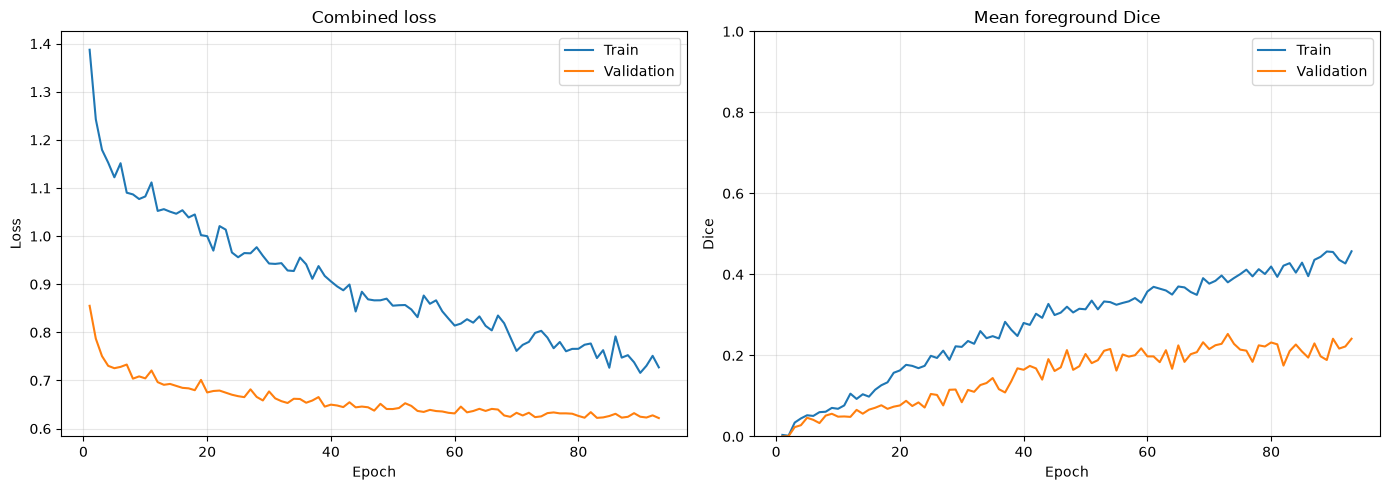

In [26]:
history_df = pd.read_csv(history_path)

required_columns = [
    "epoch",
    "train_loss",
    "val_loss",
    "train_mean_foreground_dice",
    "val_mean_foreground_dice",
]

missing = [column for column in required_columns if column not in history_df.columns]
if missing:
    raise KeyError(
        f"Missing columns: {missing}\n"
        f"Available columns: {history_df.columns.tolist()}"
    )

figure, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="Validation")
axes[0].set_title("Combined loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(
    history_df["epoch"],
    history_df["train_mean_foreground_dice"],
    label="Train",
)
axes[1].plot(
    history_df["epoch"],
    history_df["val_mean_foreground_dice"],
    label="Validation",
)
axes[1].set_title("Mean foreground Dice")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Dice")
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## 25. Load the best checkpoint and evaluate the test set

In [27]:
def load_checkpoint(
    path: Path,
    load_optimizer: bool = False,
    strict: bool = True,
) -> Dict[str, object]:

    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(
            f"Checkpoint not found: {path.resolve()}"
        )

    # --------------------------------------------------
    # Load checkpoint
    # --------------------------------------------------
    # This checkpoint was created by this notebook,
    # therefore we can safely use weights_only=False.
    checkpoint = torch.load(
        path,
        map_location="cpu",
        weights_only=False,
    )

    # --------------------------------------------------
    # Extract model weights
    # --------------------------------------------------
    saved_state = {
        key.removeprefix("module."): value
        for key, value in checkpoint["model_state_dict"].items()
    }

    # --------------------------------------------------
    # Load model
    # --------------------------------------------------
    load_result = unwrap_model(model).load_state_dict(
        saved_state,
        strict=strict,
    )

    unwrap_model(model).to(DEVICE)

    if not strict:
        print("Missing keys:")
        print(load_result.missing_keys)

        print("Unexpected keys:")
        print(load_result.unexpected_keys)

    # --------------------------------------------------
    # Restore optimizer etc. when resuming training
    # --------------------------------------------------
    if load_optimizer:

        optimizer.load_state_dict(
            checkpoint["optimizer_state_dict"]
        )

        move_optimizer_state_to_device(
            optimizer,
            DEVICE
        )

        if checkpoint.get(
            "scheduler_state_dict"
        ) is not None:

            scheduler.load_state_dict(
                checkpoint["scheduler_state_dict"]
            )

        if checkpoint.get(
            "scaler_state_dict"
        ) is not None:

            scaler.load_state_dict(
                checkpoint["scaler_state_dict"]
            )

    print(
        "Loaded checkpoint:",
        path.resolve()
    )

    print(
        "Completed epoch:",
        checkpoint.get("epoch")
    )

    print(
        "Best validation Dice:",
        checkpoint.get("best_val_dice")
    )

    return checkpoint

In [28]:
best_checkpoint = load_checkpoint(
    best_path,
    load_optimizer=False,
    strict=True,
)

model.eval()

test_metrics = run_epoch(
    model=model,
    loader=test_loader,
    training=False,
    optimizer=None,
    scheduler=None,
    scaler=scaler,
)

print("TEST SUMMARY")
for key in (
    "loss",
    "mean_foreground_dice",
    "mean_foreground_iou",
    "mean_foreground_precision",
    "mean_foreground_recall",
    "weighted_foreground_dice",
):
    print(f"{key}: {test_metrics[key]:.4f}")

test_per_class = test_metrics["per_class_metrics"]
test_per_class.to_csv(
    OUTPUT_ROOT / "test_per_class_metrics.csv",
    index=False,
)

display(
    test_per_class[
        [
            "class_id",
            "class_name",
            "support_pixels",
            "predicted_pixels",
            "dice",
            "iou",
            "precision",
            "recall",
        ]
    ].round(4)
)

Loaded checkpoint: /workspace/bash_phd/ml_pipeline/outputs/bridgenet_stroke/checkpoints/best_bridgenet.pt
Completed epoch: 72
Best validation Dice: 0.25312224291526225


validate:   0%|          | 0/36 [00:00<?, ?it/s]

/venv/main/lib/python3.12/site-packages/torch/nn/functional.py:3504: UserWarning: nll_loss2d_forward_out_cuda_template does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return torch._C._nn.cross_entropy_loss(


TEST SUMMARY
loss: 0.6061
mean_foreground_dice: 0.2292
mean_foreground_iou: 0.1485
mean_foreground_precision: 0.2310
mean_foreground_recall: 0.2606
weighted_foreground_dice: 0.3516


,class_id,class_name,support_pixels,predicted_pixels,dice,iou,precision,recall
0,1,cerebral_edema,41806,45781,0.5076,0.3401,0.4856,0.5317
1,2,cortical_involvement,2801,3486,0.0372,0.0190,0.0336,0.0418
2,3,hemorrhagic_transformation,395,1570,0.0000,0.0000,0.0000,0.0000
3,4,hyperdense_artery_sign,173,0,0.0000,0.0000,NaN,0.0000
4,5,intracerebral_hemorrhage,18382,26505,0.6155,0.4446,0.5212,0.7515
5,6,intraventricular_hemorrhage,6604,10018,0.6212,0.4506,0.5154,0.7818
6,7,ischemic_infarct,44459,23308,0.2615,0.1504,0.3801,0.1993
7,8,large_lesion_1_3_mca_territory,13952,15955,0.4848,0.3199,0.4543,0.5196
8,9,large_vessel_occlusion,6102,5015,0.3103,0.1837,0.3440,0.2827
9,10,mass_effect,14272,20784,0.1475,0.0796,0.1244,0.1811


## 26. Per-sample and per-class HD95 evaluation

In [29]:
@torch.no_grad()
def evaluate_hd95(
    model: nn.Module,
    loader: DataLoader,
) -> pd.DataFrame:
    rows: List[Dict[str, Any]] = []

    model.eval()

    for batch in tqdm(loader, desc="HD95"):
        images = batch["image"].to(DEVICE, non_blocking=True).float()
        targets = batch["mask"].cpu().numpy()
        sample_ids = batch["sample_id"]

        amp_enabled = scaler.is_enabled() and DEVICE.type == "cuda"

        with torch.autocast(
            device_type=DEVICE.type,
            dtype=torch.float16 if DEVICE.type == "cuda" else torch.bfloat16,
            enabled=amp_enabled,
        ):
            logits = extract_logits(model(images))

        predictions = torch.argmax(logits, dim=1).cpu().numpy()

        for sample_id, prediction, target in zip(
            sample_ids,
            predictions,
            targets,
        ):
            for class_id in range(1, CFG.num_classes):
                if not np.any(target == class_id) and not np.any(prediction == class_id):
                    continue

                rows.append(
                    {
                        "sample_id": sample_id,
                        "class_id": class_id,
                        "class_name": CLASS_NAMES[class_id],
                        "hd95_pixels": hd95_binary(
                            prediction == class_id,
                            target == class_id,
                        ),
                    }
                )

    return pd.DataFrame(rows)


hd95_report = evaluate_hd95(model, test_loader)
hd95_report.to_csv(OUTPUT_ROOT / "test_hd95_per_sample_class.csv", index=False)

finite_hd95 = hd95_report[np.isfinite(hd95_report["hd95_pixels"])]

hd95_summary = (
    finite_hd95.groupby(["class_id", "class_name"])["hd95_pixels"]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)

failure_counts = (
    hd95_report.assign(complete_failure=np.isinf(hd95_report["hd95_pixels"]))
    .groupby(["class_id", "class_name"])["complete_failure"]
    .sum()
    .reset_index(name="complete_failure_count")
)

hd95_summary = hd95_summary.merge(
    failure_counts,
    on=["class_id", "class_name"],
    how="outer",
)

display(hd95_summary)

HD95:   0%|          | 0/36 [00:00<?, ?it/s]

,class_id,class_name,count,mean,median,std,complete_failure_count
0,1,cerebral_edema,26.0,13.399525,8.062258,10.349262,25
1,2,cortical_involvement,4.0,55.557610,48.438836,41.889147,20
2,3,hemorrhagic_transformation,NaN,NaN,NaN,NaN,8
3,4,hyperdense_artery_sign,NaN,NaN,NaN,NaN,1
4,5,intracerebral_hemorrhage,26.0,10.796821,4.266844,16.286365,20
5,6,intraventricular_hemorrhage,10.0,15.857314,6.171979,21.691416,13
6,7,ischemic_infarct,27.0,54.139799,32.649655,49.097240,44
7,8,large_lesion_1_3_mca_territory,2.0,15.308768,15.308768,2.391763,5
8,9,large_vessel_occlusion,2.0,18.179504,18.179504,19.802677,5
9,10,mass_effect,12.0,22.764275,17.870382,11.436562,44


## 27. Visualize biomarker predictions

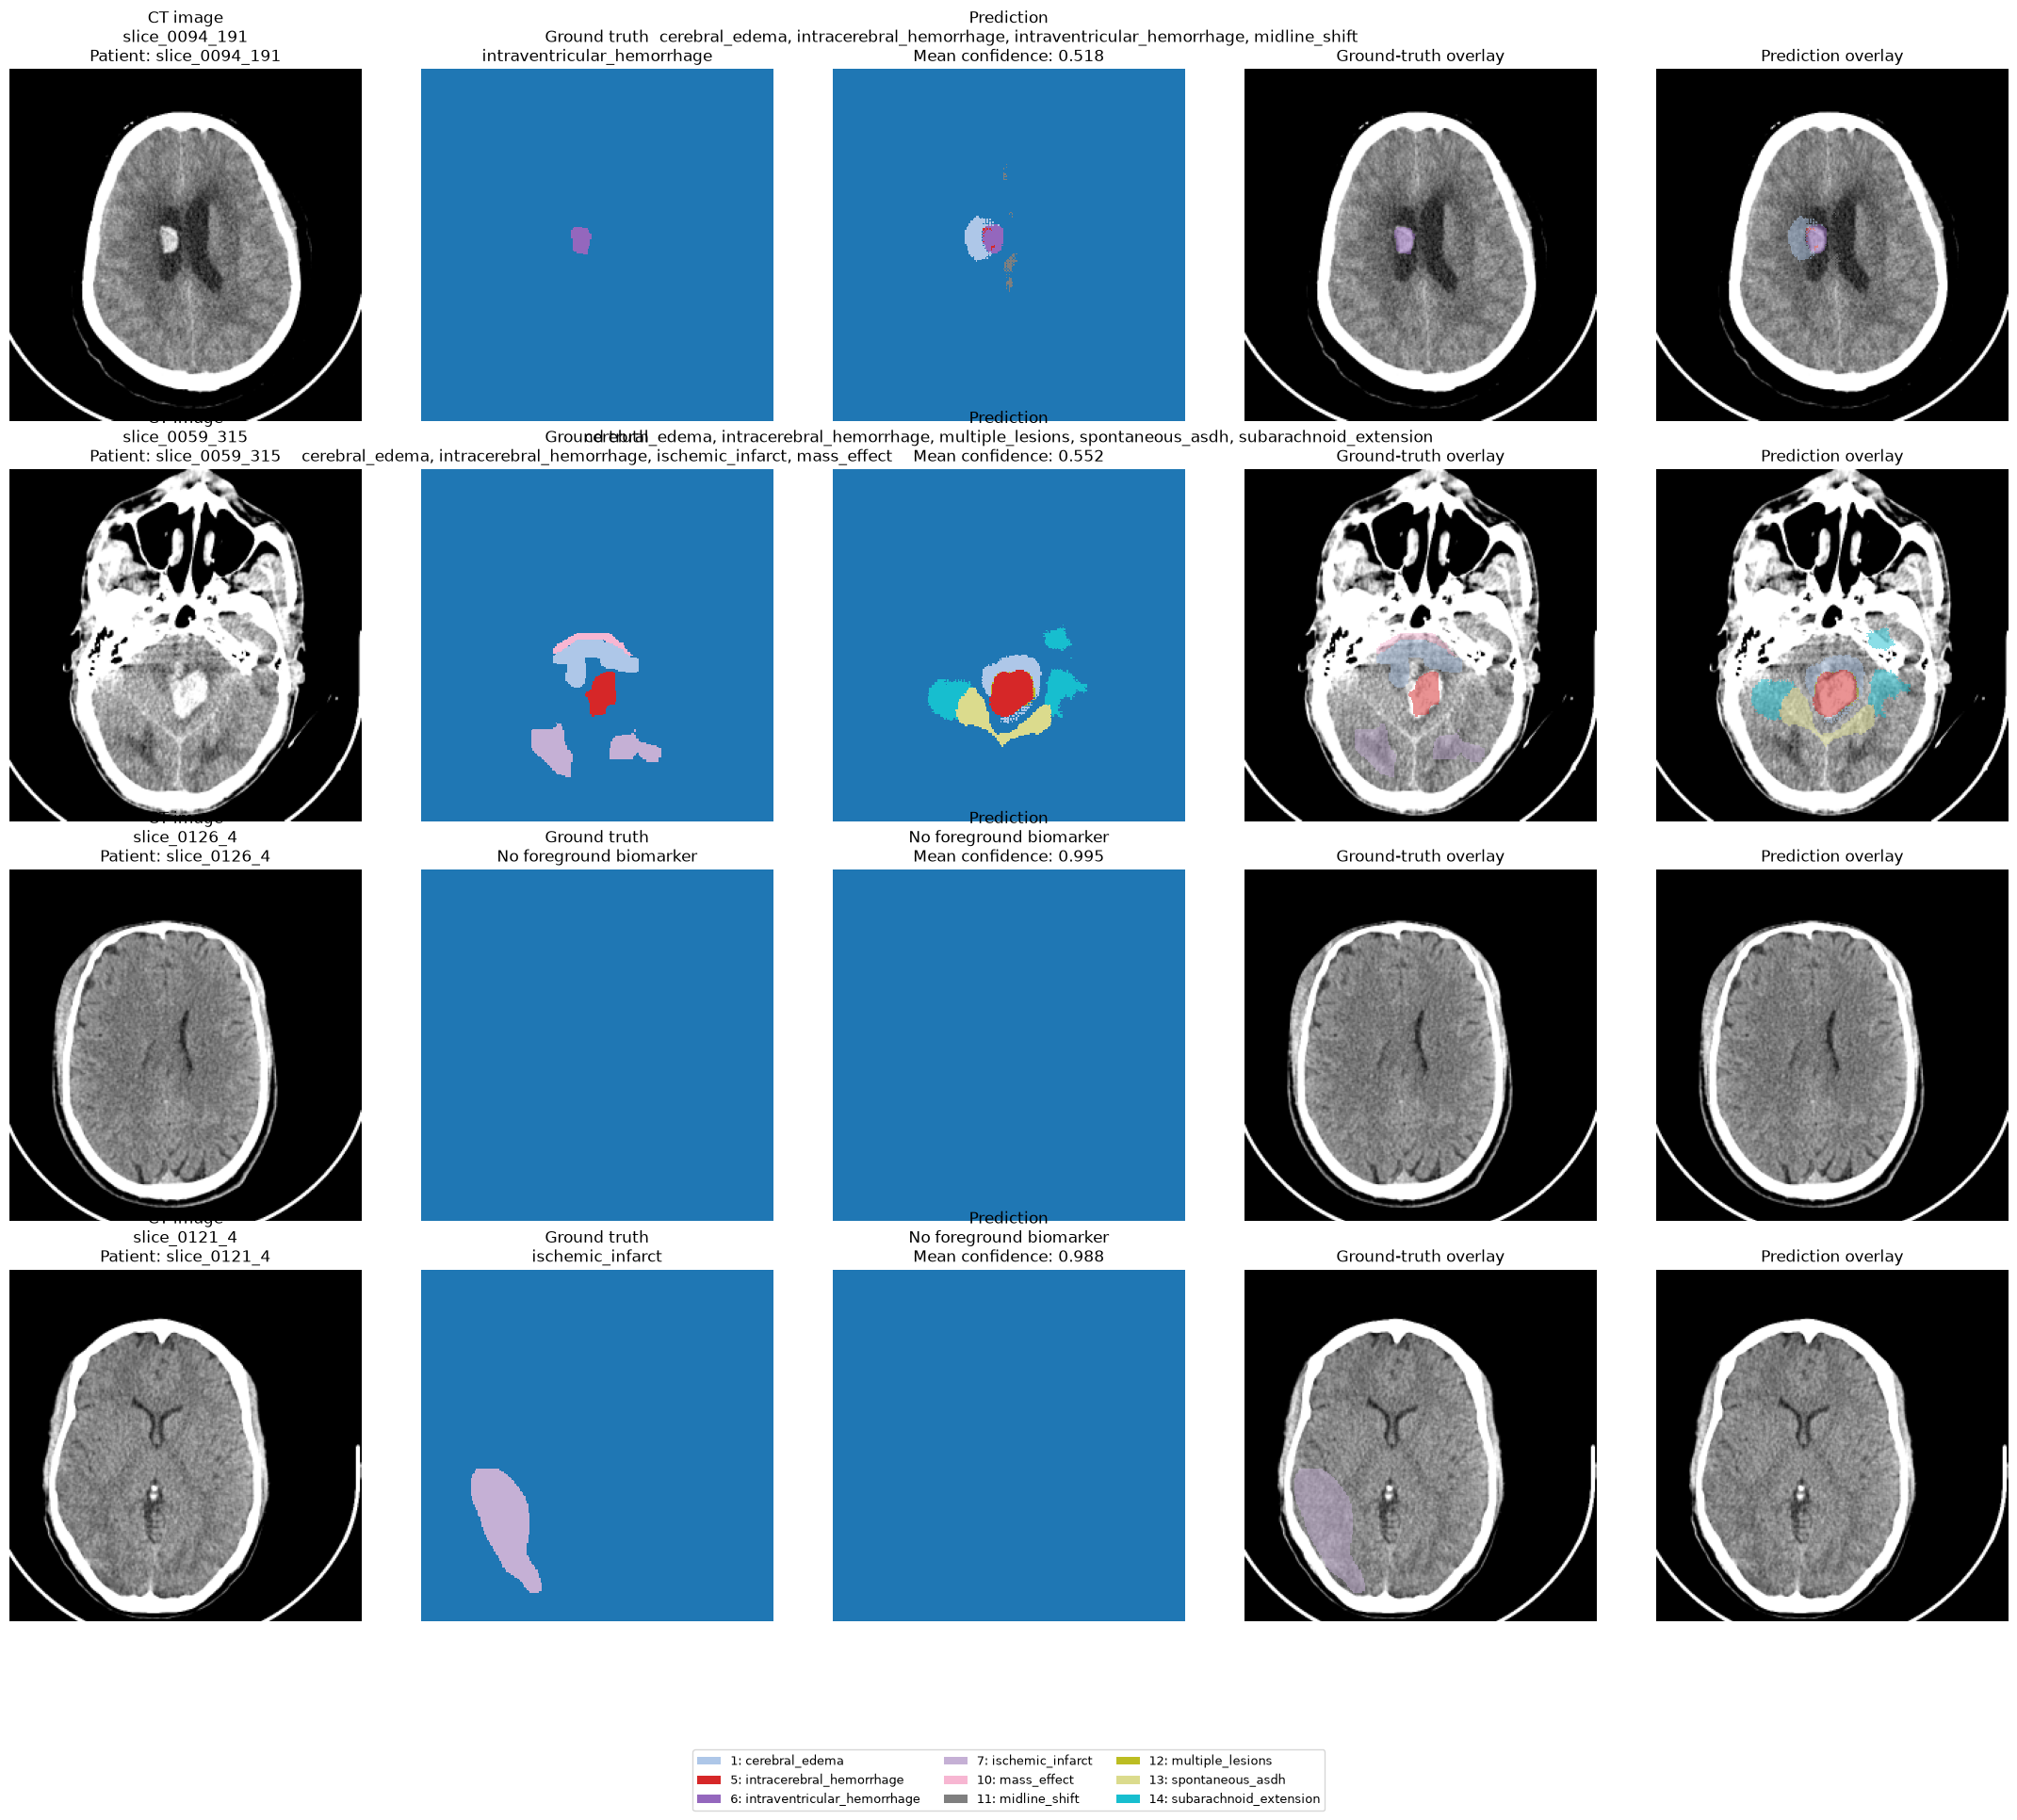

In [30]:
def prepare_image_for_display(
    image_tensor: torch.Tensor,
    mean: float = 0.5,
    std: float = 0.5,
) -> Tuple[np.ndarray, Optional[str]]:
    image = image_tensor.detach().cpu().float().numpy()
    image = np.transpose(image, (1, 2, 0))
    image = np.clip(image * std + mean, 0.0, 1.0)

    if image.shape[2] == 1 or np.allclose(image[..., 0], image[..., 1]):
        return image[..., 0], "gray"

    return image, None


def labels_in_mask(mask: np.ndarray) -> str:
    class_ids = [
        int(class_id)
        for class_id in np.unique(mask)
        if int(class_id) != 0
    ]

    if not class_ids:
        return "No foreground biomarker"

    return ", ".join(CLASS_NAMES[class_id] for class_id in class_ids)


@torch.no_grad()
def show_model_predictions(
    model: nn.Module,
    dataset: Dataset,
    n: int = 4,
    seed: int = 42,
) -> None:
    if len(dataset) == 0:
        print("Dataset is empty.")
        return

    rng = random.Random(seed)
    indices = rng.sample(range(len(dataset)), k=min(n, len(dataset)))

    cmap = plt.get_cmap("tab20", CFG.num_classes)
    norm = BoundaryNorm(np.arange(-0.5, CFG.num_classes + 0.5), cmap.N)

    figure, axes = plt.subplots(
        len(indices),
        5,
        figsize=(22, 4.8 * len(indices)),
        squeeze=False,
    )

    displayed_classes: Set[int] = set()
    model.eval()

    for row, index in enumerate(indices):
        item = dataset[index]

        image_tensor = item["image"]
        target = item["mask"].cpu().numpy().astype(np.int64)

        model_input = image_tensor.unsqueeze(0).to(DEVICE).float()

        amp_enabled = scaler.is_enabled() and DEVICE.type == "cuda"

        with torch.autocast(
            device_type=DEVICE.type,
            dtype=torch.float16 if DEVICE.type == "cuda" else torch.bfloat16,
            enabled=amp_enabled,
        ):
            logits = extract_logits(model(model_input))

        probabilities = torch.softmax(logits.float(), dim=1)
        confidence, prediction = probabilities.max(dim=1)

        prediction = prediction[0].cpu().numpy().astype(np.int64)
        confidence = confidence[0].cpu().numpy()

        image, image_cmap = prepare_image_for_display(image_tensor)

        target_overlay = np.ma.masked_where(target == 0, target)
        prediction_overlay = np.ma.masked_where(prediction == 0, prediction)

        displayed_classes.update(
            int(class_id)
            for class_id in np.unique(target)
            if int(class_id) != 0
        )
        displayed_classes.update(
            int(class_id)
            for class_id in np.unique(prediction)
            if int(class_id) != 0
        )

        predicted_foreground = prediction > 0
        mean_confidence = (
            float(confidence[predicted_foreground].mean())
            if predicted_foreground.any()
            else float(confidence.mean())
        )

        axes[row, 0].imshow(image, cmap=image_cmap)
        axes[row, 0].set_title(
            f"CT image\n{item['sample_id']}\nPatient: {item['patient_id']}"
        )

        axes[row, 1].imshow(
            target,
            cmap=cmap,
            norm=norm,
            interpolation="nearest",
        )
        axes[row, 1].set_title("Ground truth\n" + labels_in_mask(target))

        axes[row, 2].imshow(
            prediction,
            cmap=cmap,
            norm=norm,
            interpolation="nearest",
        )
        axes[row, 2].set_title(
            "Prediction\n"
            + labels_in_mask(prediction)
            + f"\nMean confidence: {mean_confidence:.3f}"
        )

        axes[row, 3].imshow(image, cmap=image_cmap)
        axes[row, 3].imshow(
            target_overlay,
            cmap=cmap,
            norm=norm,
            alpha=0.50,
            interpolation="nearest",
        )
        axes[row, 3].set_title("Ground-truth overlay")

        axes[row, 4].imshow(image, cmap=image_cmap)
        axes[row, 4].imshow(
            prediction_overlay,
            cmap=cmap,
            norm=norm,
            alpha=0.50,
            interpolation="nearest",
        )
        axes[row, 4].set_title("Prediction overlay")

        for axis in axes[row]:
            axis.axis("off")

    legend_handles = [
        Patch(
            facecolor=cmap(class_id),
            label=f"{class_id}: {CLASS_NAMES[class_id]}",
        )
        for class_id in sorted(displayed_classes)
        if 0 < class_id < CFG.num_classes
    ]

    if legend_handles:
        figure.legend(
            handles=legend_handles,
            loc="lower center",
            ncol=3,
            bbox_to_anchor=(0.5, 0.0),
            fontsize=9,
        )
        plt.tight_layout(rect=(0, 0.10, 1, 1))
    else:
        plt.tight_layout()

    plt.show()


show_model_predictions(model, test_dataset, n=4, seed=CFG.seed)

## 28. Inspect learned biomarker and multi-scale relationships

The relational module now exposes three complementary internal signals:

1. **Biomarker-to-biomarker attention** — which biomarker representations are used as relational sources for each receiving/query biomarker.
2. **Biomarker-specific scale gates** — the learned weighting of local (1/2), regional (1/4), and global (1/8) evidence for each biomarker.
3. **Cross-scale attention** — interactions among the three scale-specific evidence representations before biomarker self-attention.

These are model-internal signals, not proof of causal or clinical relationships. Use them for hypothesis generation and evaluate proposed mechanisms through controlled ablations and clinical review.


Biomarker-to-biomarker attention


,cerebral_edema,cortical_involvement,hemorrhagic_transformation,hyperdense_artery_sign,intracerebral_hemorrhage,intraventricular_hemorrhage,ischemic_infarct,large_lesion_1_3_mca_territory,large_vessel_occlusion,mass_effect,midline_shift,multiple_lesions,spontaneous_asdh,subarachnoid_extension,temporal_lobe_involvement
cerebral_edema,0.041,0.037,0.041,0.017,0.161,0.083,0.147,0.051,0.068,0.053,0.036,0.062,0.055,0.104,0.045
cortical_involvement,0.042,0.037,0.041,0.026,0.186,0.062,0.277,0.022,0.097,0.022,0.035,0.044,0.058,0.025,0.027
hemorrhagic_transformation,0.041,0.047,0.042,0.013,0.104,0.073,0.250,0.081,0.041,0.095,0.048,0.051,0.028,0.047,0.040
hyperdense_artery_sign,0.078,0.059,0.043,0.028,0.141,0.110,0.142,0.037,0.101,0.037,0.042,0.073,0.031,0.035,0.043
intracerebral_hemorrhage,0.081,0.046,0.063,0.043,0.087,0.079,0.088,0.053,0.086,0.089,0.080,0.066,0.035,0.060,0.045
intraventricular_hemorrhage,0.081,0.072,0.049,0.030,0.101,0.065,0.095,0.040,0.056,0.079,0.061,0.052,0.054,0.122,0.043
ischemic_infarct,0.073,0.046,0.048,0.022,0.105,0.065,0.154,0.098,0.044,0.075,0.053,0.060,0.048,0.067,0.041
large_lesion_1_3_mca_territory,0.053,0.031,0.045,0.016,0.025,0.020,0.350,0.076,0.087,0.139,0.032,0.029,0.024,0.032,0.041
large_vessel_occlusion,0.049,0.069,0.037,0.017,0.038,0.031,0.221,0.210,0.042,0.082,0.069,0.038,0.022,0.033,0.041
mass_effect,0.040,0.044,0.037,0.025,0.158,0.076,0.159,0.071,0.044,0.057,0.050,0.064,0.048,0.070,0.058


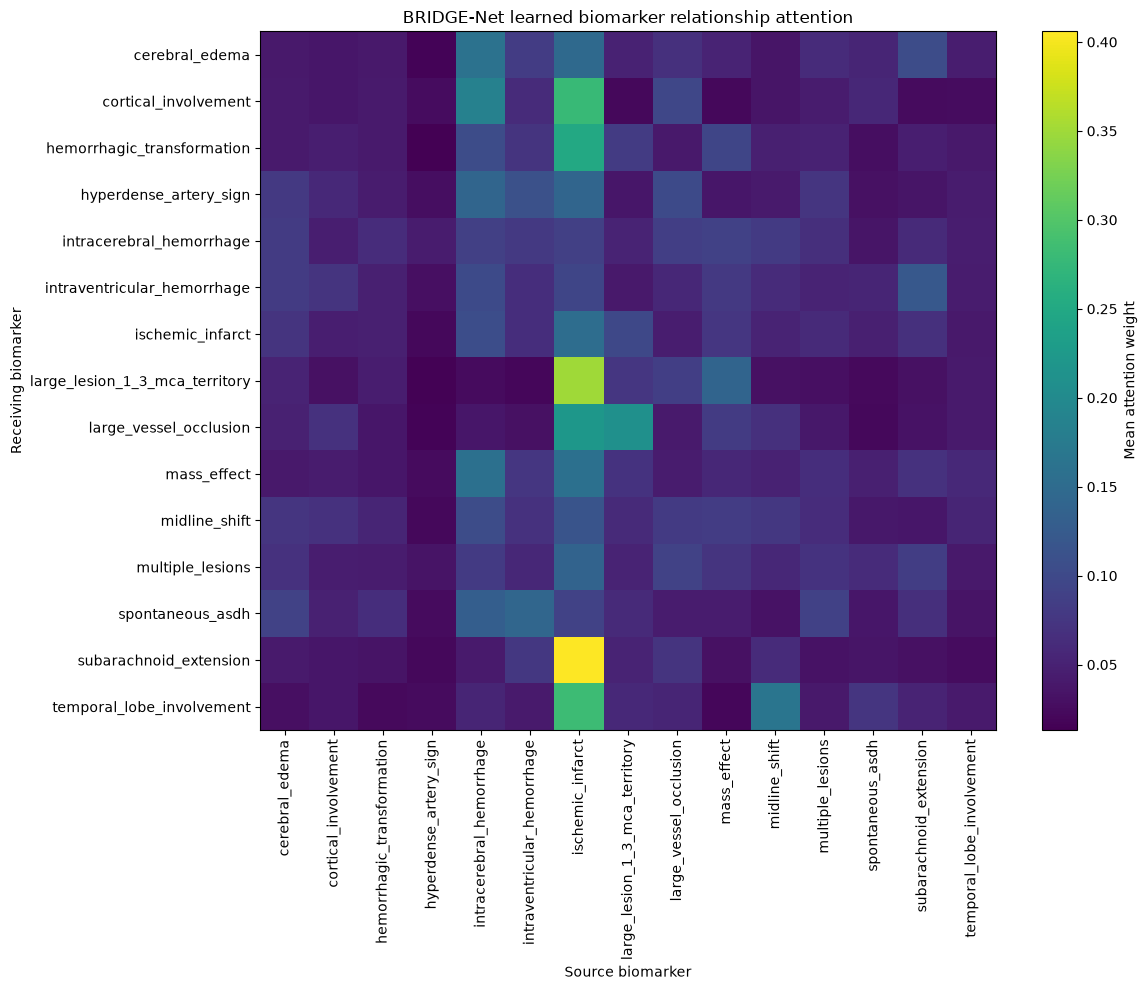

Biomarker-specific local/regional/global scale gates


,local_1_2,regional_1_4,global_1_8
cerebral_edema,0.505,0.326,0.169
cortical_involvement,0.314,0.627,0.059
hemorrhagic_transformation,0.637,0.031,0.333
hyperdense_artery_sign,0.021,0.918,0.061
intracerebral_hemorrhage,0.987,0.008,0.005
intraventricular_hemorrhage,0.988,0.008,0.004
ischemic_infarct,0.034,0.014,0.953
large_lesion_1_3_mca_territory,0.005,0.984,0.011
large_vessel_occlusion,0.019,0.234,0.747
mass_effect,0.090,0.829,0.081


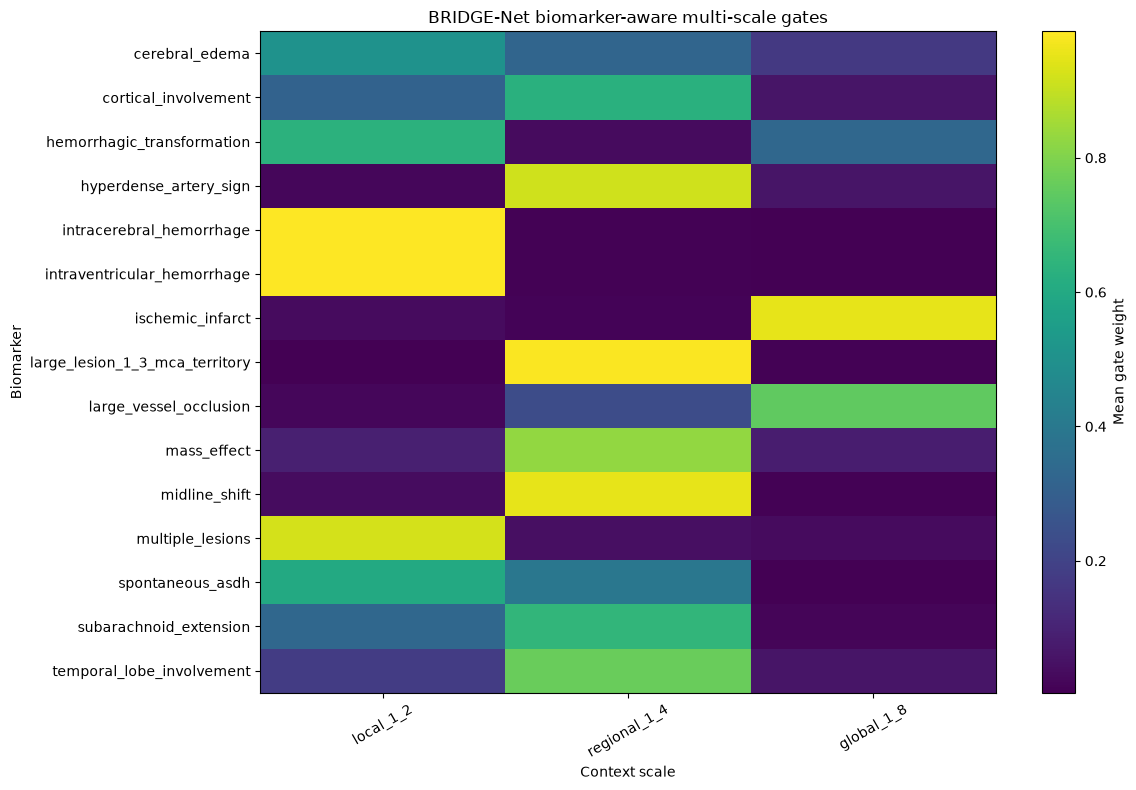

Cross-scale attention


,local_1_2,regional_1_4,global_1_8
local_1_2,0.323,0.340,0.337
regional_1_4,0.351,0.320,0.329
global_1_8,0.359,0.339,0.302


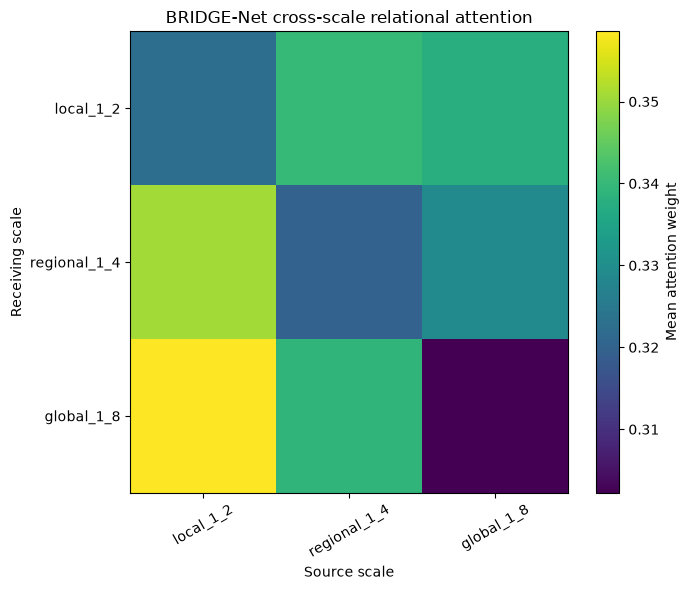

In [31]:
@torch.no_grad()
def collect_relation_diagnostics(
    model: nn.Module,
    loader: DataLoader,
    maximum_batches: Optional[int] = 20,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Collect mean biomarker relation, biomarker scale-gate and cross-scale attention matrices."""
    core_model = unwrap_model(model)
    core_model.eval()

    relation_matrices: List[np.ndarray] = []
    scale_gate_matrices: List[np.ndarray] = []
    cross_scale_matrices: List[np.ndarray] = []

    for batch_index, batch in enumerate(loader):
        if maximum_batches is not None and batch_index >= maximum_batches:
            break

        images = batch["image"].to(DEVICE, non_blocking=True).float()
        _ = core_model(images)

        if core_model.last_relation_attention is not None:
            relation_matrices.append(
                core_model.last_relation_attention.float().mean(dim=0).cpu().numpy()
            )

        if core_model.last_scale_gates is not None:
            # [B, K, 3] -> mean over batch
            scale_gate_matrices.append(
                core_model.last_scale_gates.float().mean(dim=0).cpu().numpy()
            )

        if core_model.last_cross_scale_attention is not None:
            # [B*K, 3, 3] -> reshape, then average over B and K
            attention = core_model.last_cross_scale_attention.float()
            attention = attention.view(
                images.shape[0],
                core_model.relational_transfer.num_foreground_classes,
                core_model.relational_transfer.num_scales,
                core_model.relational_transfer.num_scales,
            )
            cross_scale_matrices.append(
                attention.mean(dim=(0, 1)).cpu().numpy()
            )

    if not relation_matrices:
        raise RuntimeError("No biomarker relation matrices were collected.")
    if not scale_gate_matrices:
        raise RuntimeError("No biomarker scale-gate matrices were collected.")
    if not cross_scale_matrices:
        raise RuntimeError("No cross-scale attention matrices were collected.")

    return (
        np.mean(relation_matrices, axis=0),
        np.mean(scale_gate_matrices, axis=0),
        np.mean(cross_scale_matrices, axis=0),
    )


relation_matrix, scale_gate_matrix, cross_scale_matrix = collect_relation_diagnostics(
    model,
    test_loader,
)
foreground_names = [CLASS_NAMES[class_id] for class_id in range(1, CFG.num_classes)]
scale_names = ["local_1_2", "regional_1_4", "global_1_8"]

relation_df = pd.DataFrame(
    relation_matrix,
    index=foreground_names,
    columns=foreground_names,
)
relation_df.to_csv(OUTPUT_ROOT / "test_mean_biomarker_relation_matrix.csv")

scale_gate_df = pd.DataFrame(
    scale_gate_matrix,
    index=foreground_names,
    columns=scale_names,
)
scale_gate_df.to_csv(OUTPUT_ROOT / "test_mean_biomarker_scale_gates.csv")

cross_scale_df = pd.DataFrame(
    cross_scale_matrix,
    index=scale_names,
    columns=scale_names,
)
cross_scale_df.to_csv(OUTPUT_ROOT / "test_mean_cross_scale_attention.csv")

print("Biomarker-to-biomarker attention")
display(relation_df.round(3))

plt.figure(figsize=(12, 10))
plt.imshow(relation_matrix, aspect="auto")
plt.colorbar(label="Mean attention weight")
plt.xticks(range(len(foreground_names)), foreground_names, rotation=90)
plt.yticks(range(len(foreground_names)), foreground_names)
plt.xlabel("Source biomarker")
plt.ylabel("Receiving biomarker")
plt.title("BRIDGE-Net learned biomarker relationship attention")
plt.tight_layout()
plt.show()

print("Biomarker-specific local/regional/global scale gates")
display(scale_gate_df.round(3))

plt.figure(figsize=(12, 8))
plt.imshow(scale_gate_matrix, aspect="auto")
plt.colorbar(label="Mean gate weight")
plt.xticks(range(len(scale_names)), scale_names, rotation=30)
plt.yticks(range(len(foreground_names)), foreground_names)
plt.xlabel("Context scale")
plt.ylabel("Biomarker")
plt.title("BRIDGE-Net biomarker-aware multi-scale gates")
plt.tight_layout()
plt.show()

print("Cross-scale attention")
display(cross_scale_df.round(3))

plt.figure(figsize=(7, 6))
plt.imshow(cross_scale_matrix, aspect="auto")
plt.colorbar(label="Mean attention weight")
plt.xticks(range(len(scale_names)), scale_names, rotation=30)
plt.yticks(range(len(scale_names)), scale_names)
plt.xlabel("Source scale")
plt.ylabel("Receiving scale")
plt.title("BRIDGE-Net cross-scale relational attention")
plt.tight_layout()
plt.show()


## 29. Export a BRIDGE-Net deployment checkpoint and run metadata


In [32]:
deployment_payload = {
    "model_state_dict": unwrap_model(model).state_dict(),
    "architecture": {
        "name": "BRIDGENet",
        "image_size": CFG.image_size,
        "input_channels": CFG.input_channels,
        "num_classes": CFG.num_classes,
        "channels": list(CFG.unet_channels),
        "dropout": CFG.unet_dropout,
        "group_norm_max_groups": CFG.group_norm_max_groups,
        "relation_dim": CFG.bridge_relation_dim,
        "num_heads": CFG.bridge_num_heads,
        "relation_grid_size": CFG.bridge_relation_grid_size,
        "relation_scales": list(CFG.bridge_scale_names),
        "relation_scale_grids": [
            CFG.bridge_relation_grid_size,
            max(4, CFG.bridge_relation_grid_size // 2),
            max(2, CFG.bridge_relation_grid_size // 4),
        ],
        "biomarker_aware_scale_gating": True,
        "cross_scale_attention": True,
        "rarity_gate_strength": CFG.bridge_rarity_gate_strength,
        "common_source_bias": CFG.bridge_common_source_bias,
        "residual_head_weight": CFG.bridge_residual_head_weight,
    },
    "preprocessing": {
        "resize": [CFG.image_size, CFG.image_size],
        "normalization_mean": [0.5, 0.5, 0.5],
        "normalization_std": [0.5, 0.5, 0.5],
        "mask_class_mapping": CLASS_NAMES,
    },
    "best_validation_dice": best_checkpoint.get("best_val_dice"),
    "test_summary": {
        key: value
        for key, value in test_metrics.items()
        if isinstance(value, (int, float, np.integer, np.floating))
    },
}

deployment_path = OUTPUT_ROOT / "bridgenet_stroke_deployment.pt"
save_checkpoint_atomic(deployment_payload, deployment_path)

run_metadata = {
    "architecture": "BRIDGENet",
    "device": str(DEVICE),
    "gpu": (
        torch.cuda.get_device_name(0)
        if torch.cuda.is_available()
        else None
    ),
    "torch_version": torch.__version__,
    "cuda_version": torch.version.cuda,
    "config": asdict(CFG),
}

with (OUTPUT_ROOT / "run_metadata.json").open("w", encoding="utf-8") as file:
    json.dump(run_metadata, file, indent=2)

print("Saved deployment checkpoint:", deployment_path)
print("Saved run metadata:", OUTPUT_ROOT / "run_metadata.json")

Saved deployment checkpoint: /workspace/bash_phd/ml_pipeline/outputs/bridgenet_stroke/bridgenet_stroke_deployment.pt
Saved run metadata: /workspace/bash_phd/ml_pipeline/outputs/bridgenet_stroke/run_metadata.json


## 30. Final checks and required ablations

Before accepting the model:

- Confirm every intended class has positive training examples.
- Select the best checkpoint using mean foreground validation Dice, not training loss.
- Review per-class Dice, precision, recall, IoU, and HD95, especially for rare biomarkers.
- Keep the test set untouched until final model selection.
- Compare BRIDGE-Net against the original U-Net using **the same patient split and training protocol**.
- Run an ablation without biomarker self-attention.
- Run an ablation with biomarker-aware scale gating disabled (for example, equal scale weights).
- Run an ablation without cross-scale attention to isolate the value of explicit multi-scale interaction.
- Run an ablation using only one relational scale at a time (local, regional, global).
- Run an ablation with rarity gating disabled (`bridge_rarity_gate_strength=0`).
- Run an ablation with common-source bias disabled (`bridge_common_source_bias=0`).
- Run an ablation with both long-tail mechanisms disabled to isolate relational attention itself.
- Report macro/per-class metrics rather than relying only on mean Dice.
- Inspect biomarker-specific scale gates to test whether different biomarkers preferentially use local, regional, or global context.
- Treat learned attention weights and scale gates as model internals, not causal clinical evidence.
- Remember that class-aware augmentation and relational transfer cannot replace missing biological diversity in extremely rare classes.
